In [1]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets


PRODUCTS = ("EMERALDS", "TOMATOES")
LEVELS = (1, 2, 3)


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in search_roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


def cumulative_depth(row: pd.Series, side: str) -> tuple[list[float], list[float]]:
    price_volume: dict[float, float] = {}

    for level in LEVELS:
        price = row.get(f"{side}_price_{level}")
        volume = row.get(f"{side}_volume_{level}")

        if pd.isna(price) or pd.isna(volume) or volume <= 0:
            continue

        price_value = float(price)
        volume_value = float(volume)
        price_volume[price_value] = price_volume.get(price_value, 0.0) + volume_value

    if not price_volume:
        return [], []

    reverse = side == "bid"
    prices = sorted(price_volume.keys(), reverse=reverse)

    cumulative = []
    running = 0.0
    for price in prices:
        running += price_volume[price]
        cumulative.append(running)

    return prices, cumulative


def draw_product_depth(ax: plt.Axes, row: pd.Series, product: str) -> None:
    ax.clear()

    bid_prices, bid_cum = cumulative_depth(row, "bid")
    ask_prices, ask_cum = cumulative_depth(row, "ask")

    if bid_prices:
        ax.step(bid_prices, bid_cum, where="post", color="tab:green", linewidth=2, label="Bids")
        ax.fill_between(bid_prices, bid_cum, step="post", alpha=0.25, color="tab:green")

    if ask_prices:
        ax.step(ask_prices, ask_cum, where="post", color="tab:red", linewidth=2, label="Asks")
        ax.fill_between(ask_prices, ask_cum, step="post", alpha=0.25, color="tab:red")

    mid_price = row.get("mid_price")
    if pd.notna(mid_price):
        ax.axvline(float(mid_price), linestyle="--", linewidth=1.5, color="tab:blue", label="Mid")

    best_bid = row.get("bid_price_1")
    best_ask = row.get("ask_price_1")
    spread_text = ""
    if pd.notna(best_bid) and pd.notna(best_ask):
        spread_text = f" | Spread: {float(best_ask) - float(best_bid):.2f}"

    ax.set_title(f"{product}{spread_text}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Cumulative Volume")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def run_visualizer(path: str = "prices_round_0_day_-1.csv") -> None:
    df = load_prices(path)

    filtered = df[df["product"].isin(PRODUCTS)].copy()
    if filtered.empty:
        raise ValueError("No rows found for EMERALDS or TOMATOES in the provided file.")

    timestamps = sorted(filtered["timestamp"].dropna().unique())
    if not timestamps:
        raise ValueError("No valid timestamp values found in the provided file.")

    data_by_product = {
        product: (
            filtered[filtered["product"] == product]
            .drop_duplicates(subset=["timestamp"], keep="last")
            .set_index("timestamp")
            .sort_index()
        )
        for product in PRODUCTS
    }

    def row_for_timestamp(product: str, timestamp: float) -> pd.Series | None:
        product_df = data_by_product[product]
        if timestamp not in product_df.index:
            return None
        return product_df.loc[timestamp]

    def plot_at_index(index: int) -> None:
        timestamp = timestamps[int(index)]

        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
        ax_emeralds = fig.add_subplot(gs[0, 0])
        ax_tomatoes = fig.add_subplot(gs[0, 1])

        emerald_row = row_for_timestamp("EMERALDS", timestamp)
        tomato_row = row_for_timestamp("TOMATOES", timestamp)

        if emerald_row is not None:
            draw_product_depth(ax_emeralds, emerald_row, "EMERALDS")
        else:
            ax_emeralds.set_title("EMERALDS (no data)")

        if tomato_row is not None:
            draw_product_depth(ax_tomatoes, tomato_row, "TOMATOES")
        else:
            ax_tomatoes.set_title("TOMATOES (no data)")

        fig.suptitle(f"Order Book Depth | timestamp={int(timestamp)}", fontsize=14)
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=len(timestamps) - 1,
        step=1,
        value=min(11, len(timestamps) - 1),
        description="Time idx",
        continuous_update=True,
        layout=widgets.Layout(width="850px"),
    )

    play = widgets.Play(
        value=slider.value,
        min=slider.min,
        max=slider.max,
        step=1,
        interval=100,  # 10 FPS
        description="Auto",
    )

    play_pause = widgets.ToggleButton(
        value=False,
        description="▶ Play",
        tooltip="Play/Pause at 10 FPS",
        layout=widgets.Layout(width="120px"),
    )

    widgets.jslink((play, "value"), (slider, "value"))

    def on_play_pause(change):
        is_playing = bool(change["new"])
        play_pause.description = "⏸ Pause" if is_playing else "▶ Play"
        if hasattr(play, "playing"):
            play.playing = is_playing
        else:
            play._playing = is_playing

    play_pause.observe(on_play_pause, names="value")

    out = widgets.interactive_output(plot_at_index, {"index": slider})
    controls = widgets.HBox([play_pause, play, slider])
    display(controls, out)

### Day -1

In [2]:
run_visualizer("prices_round_0_day_-1.csv")

Output()

### Day -2

In [3]:
run_visualizer("prices_round_0_day_-2.csv")

Output()

First glance notes:

> 9679 of 10000 timestamps have a midpoint of 10000 for emeralds day -1.
>
> Data appears to be synthetic with only certain values being the midpoint


In [4]:
import numpy as np
from matplotlib.ticker import ScalarFormatter, MaxNLocator


def plot_bid_ask_distribution_by_level(
    file_path: str,
    product: str = "EMERALDS",
    levels: tuple[int, ...] = (1, 2, 3),
    figsize: tuple[int, int] = (22, 24),
    zoom_level3: bool = True,
    title_prefix: str | None = None,
) -> None:
    df_prices = load_prices(file_path)
    product_df = df_prices[df_prices["product"] == product].copy()

    if product_df.empty:
        raise ValueError(f"No {product} rows found in the dataset: {file_path}")

    fig, axes = plt.subplots(len(levels), 1, figsize=figsize, sharey=False)
    if len(levels) == 1:
        axes = [axes]

    for idx, level in enumerate(levels):
        ax = axes[idx]
        bid_col = f"bid_price_{level}"
        ask_col = f"ask_price_{level}"

        bid_vals = product_df[bid_col].dropna() if bid_col in product_df.columns else pd.Series(dtype=float)
        ask_vals = product_df[ask_col].dropna() if ask_col in product_df.columns else pd.Series(dtype=float)

        all_vals = pd.concat([bid_vals, ask_vals], axis=0).dropna()
        if all_vals.empty:
            ax.set_title(f"Level {level} (no data)", fontsize=20)
            continue

        min_price = int(np.floor(all_vals.min()))
        max_price = int(np.ceil(all_vals.max()))
        bins = np.arange(min_price - 0.5, max_price + 1.5, 1)

        if not bid_vals.empty:
            ax.hist(bid_vals, bins=bins, alpha=0.55, color="tab:green", label="Bids")
        if not ask_vals.empty:
            ax.hist(ask_vals, bins=bins, alpha=0.55, color="tab:red", label="Asks")

        ax.set_title(f"Level {level}", fontsize=20)
        ax.set_xlabel("Price", fontsize=16)
        ax.set_ylabel("Count", fontsize=16)
        ax.grid(alpha=0.25)
        ax.legend(loc="upper left", fontsize=13)

        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax.xaxis.set_major_formatter(formatter)

        if level == 1:
            ax.set_xticks(np.arange(min_price, max_price + 1, 1))
        else:
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        if zoom_level3 and level == 3:
            level3_counts, _ = np.histogram(all_vals, bins=bins)
            nonzero = level3_counts[level3_counts > 0]
            if nonzero.size > 0:
                y_top = np.quantile(nonzero, 0.95) * 1.25
                y_floor = max(nonzero.max() * 0.25, 1)
                ax.set_ylim(0, max(y_top, y_floor))

        ax.tick_params(axis="both", labelsize=13)

    title = f"{product} Bid/Ask Price Distribution by Level"
    if title_prefix:
        title = f"{title_prefix} | {title}"

    fig.suptitle(title, fontsize=32)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

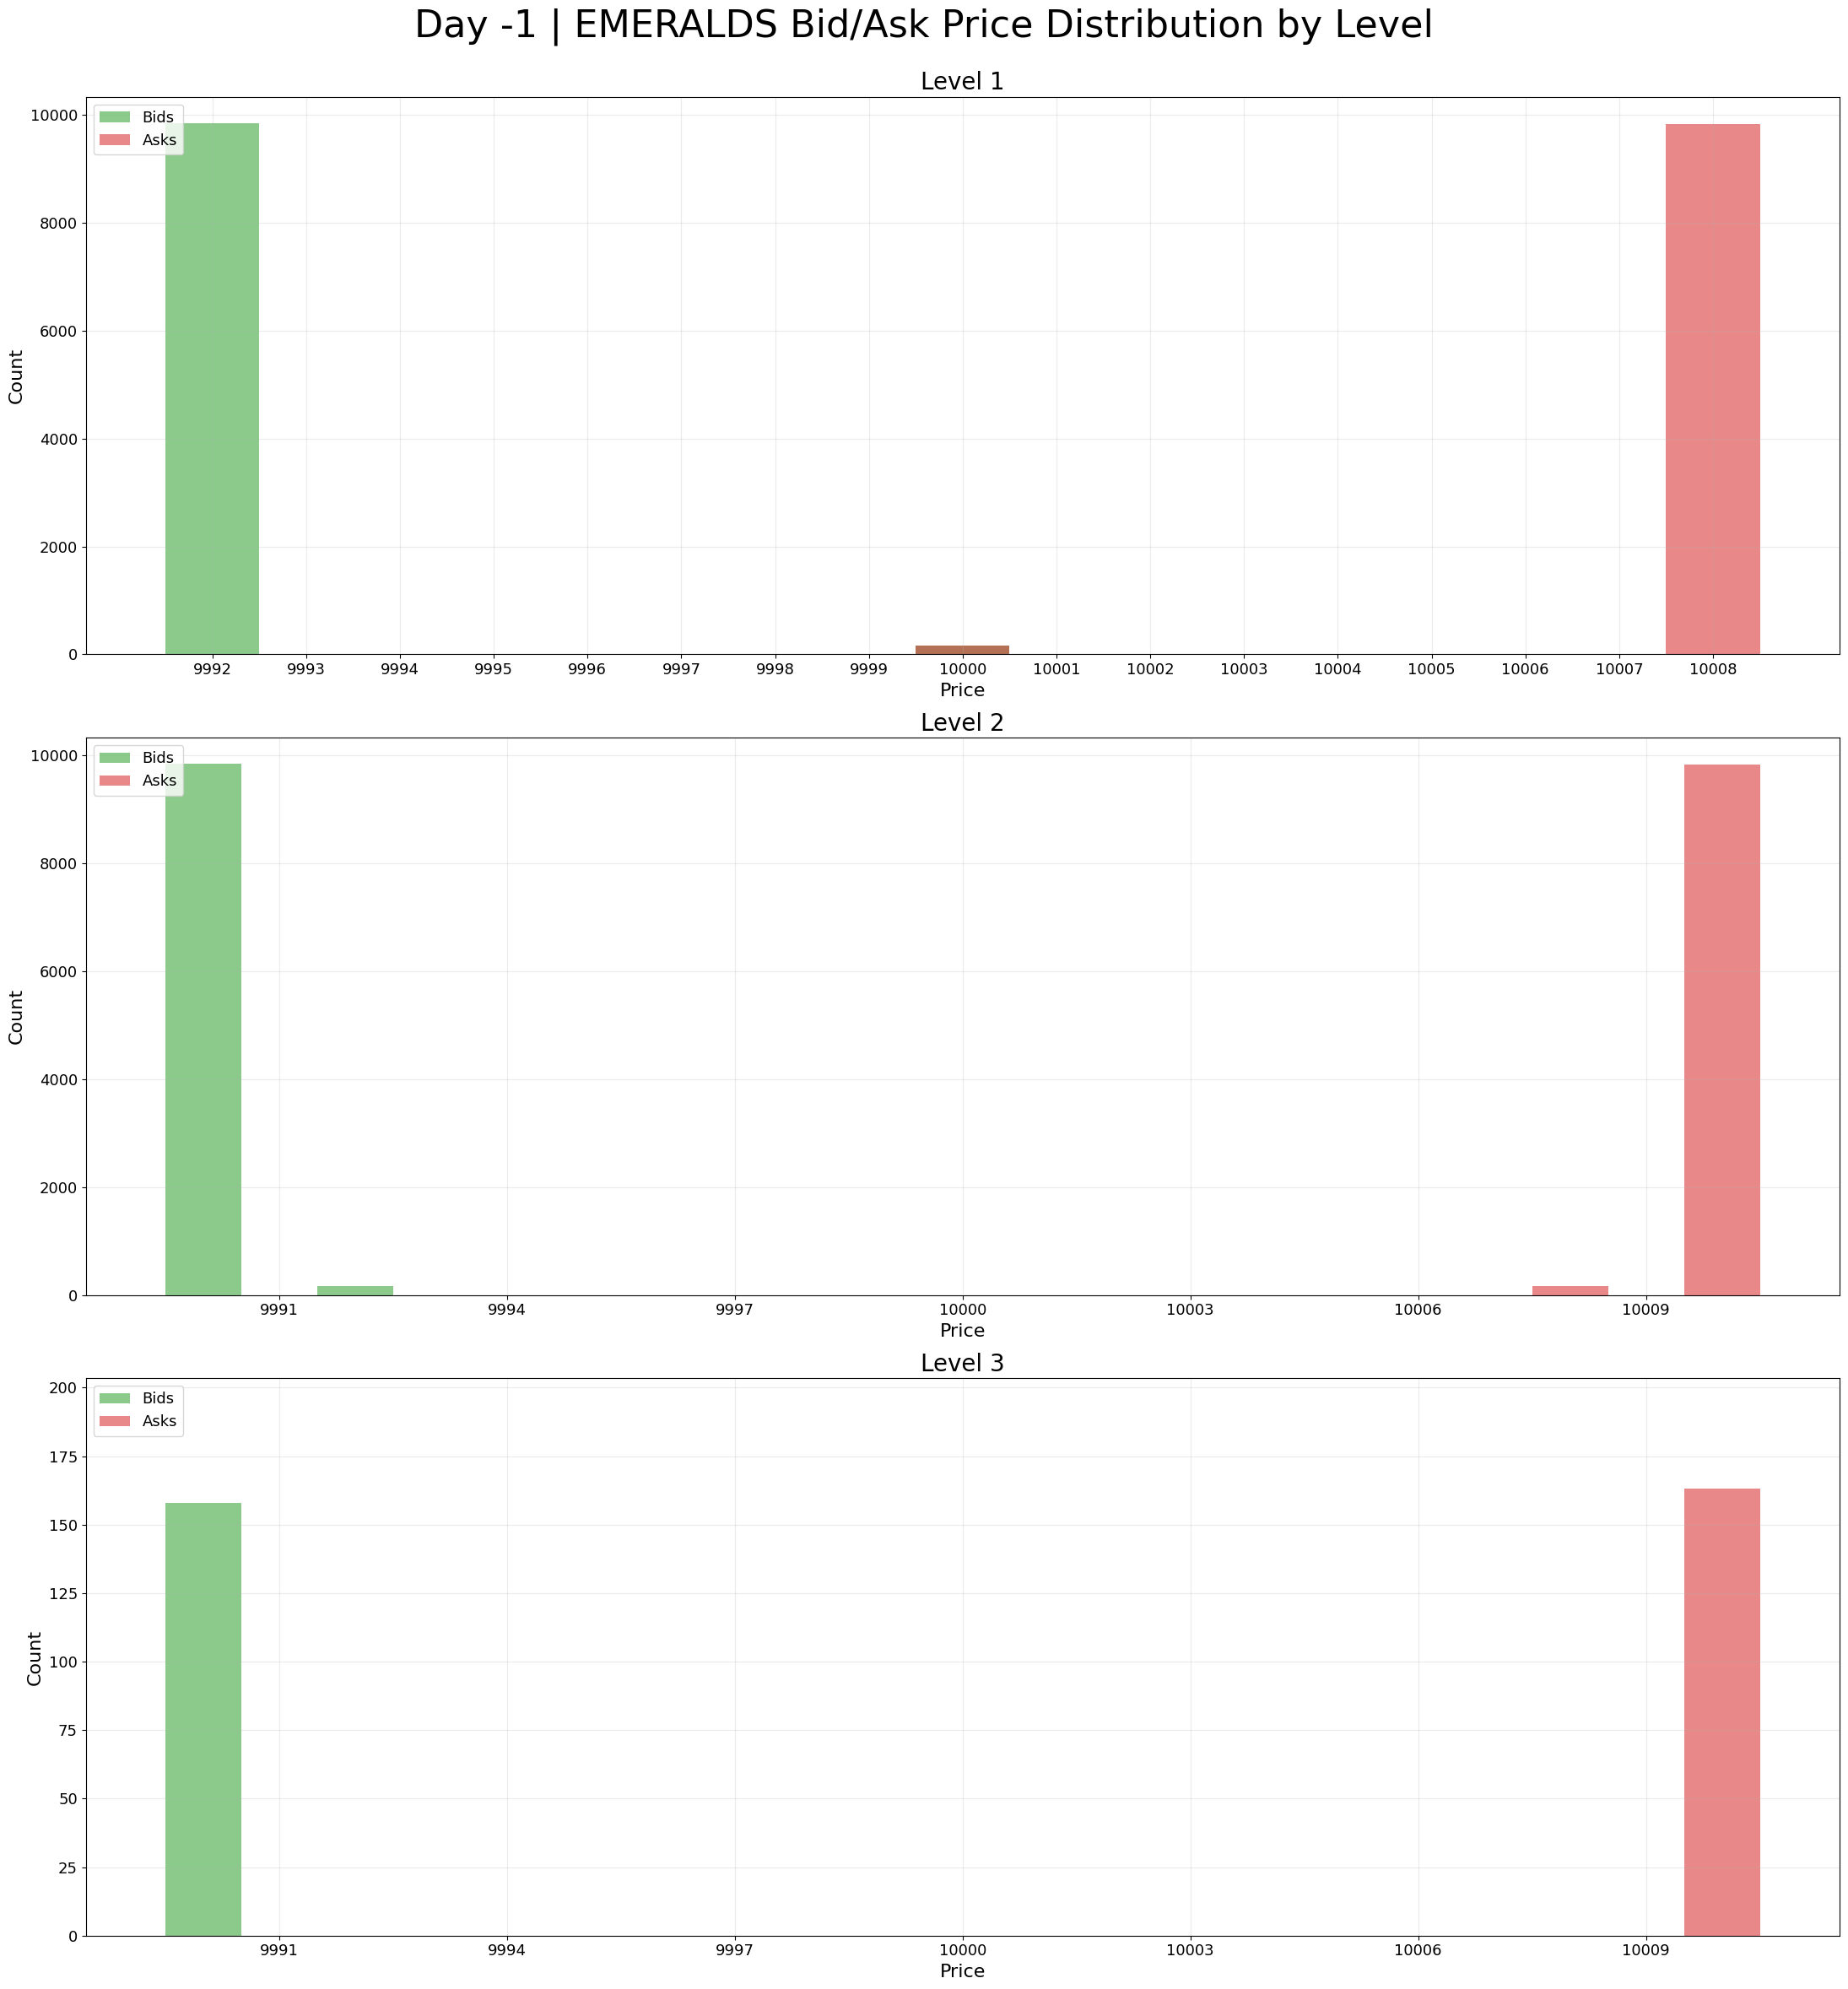

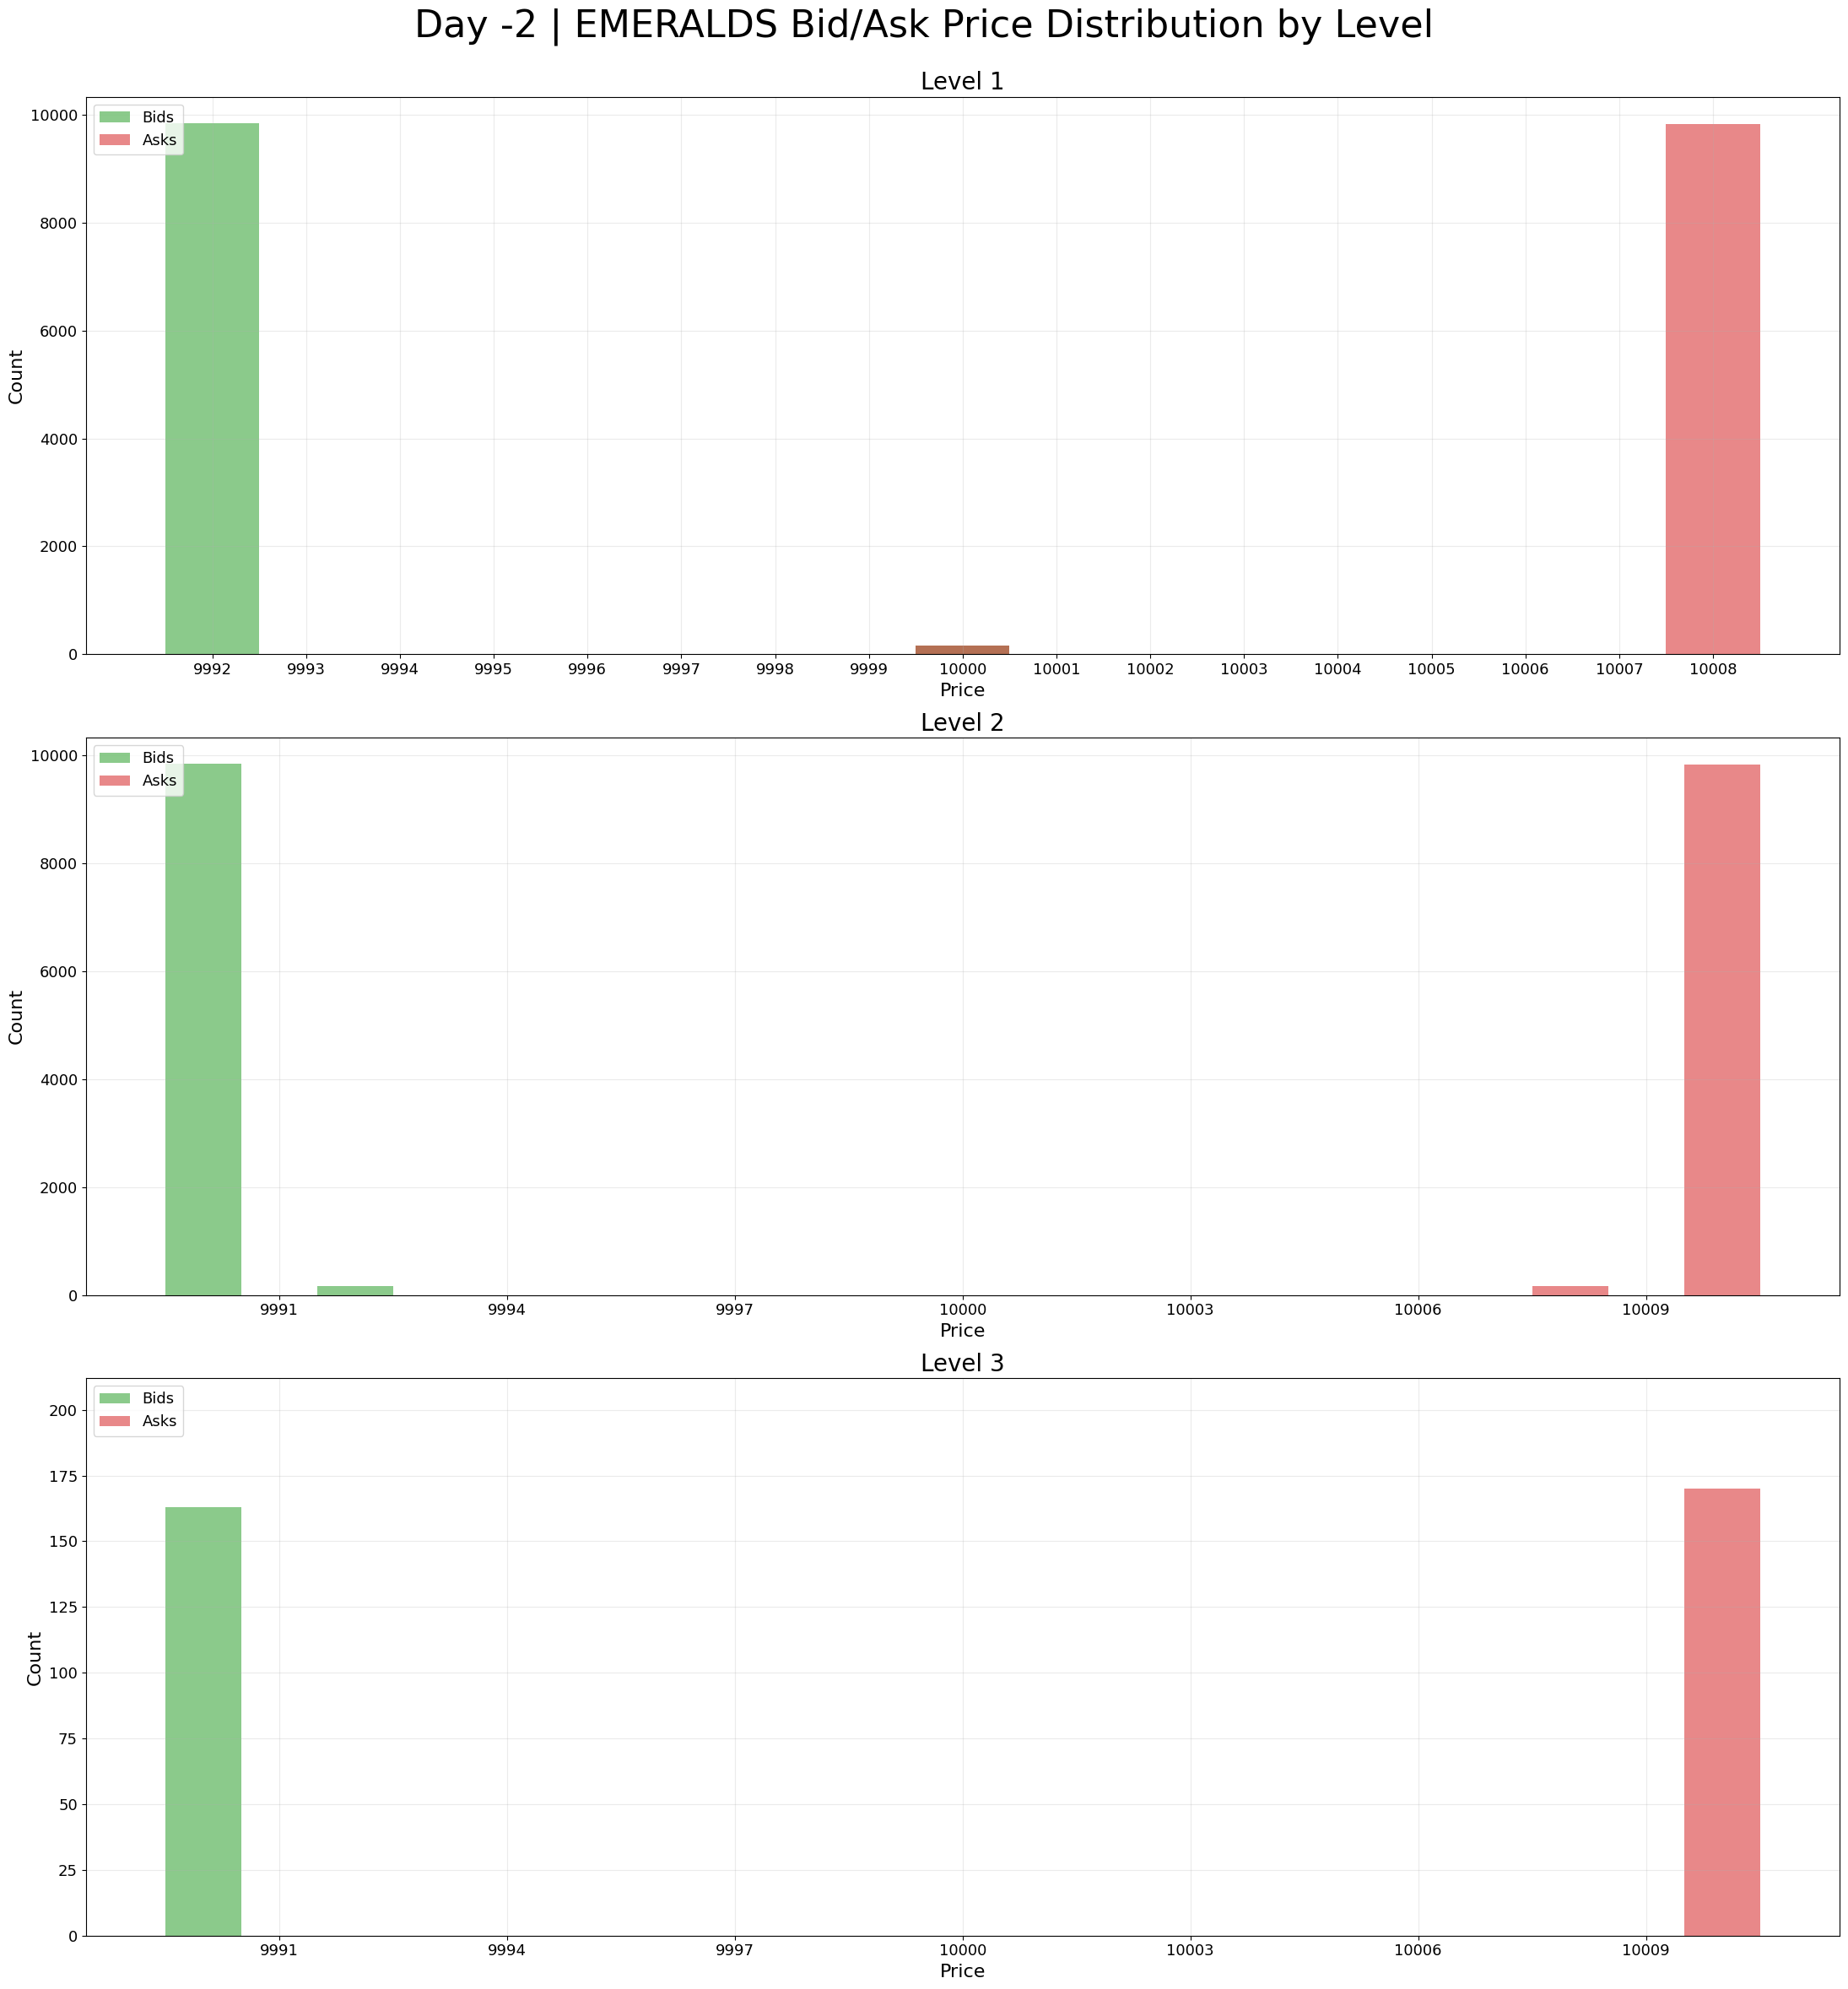

In [5]:
plot_bid_ask_distribution_by_level(
"prices_round_0_day_-1.csv",
    product="EMERALDS",
    title_prefix="Day -1",
)

plot_bid_ask_distribution_by_level(
    "prices_round_0_day_-2.csv",
    product="EMERALDS",
    title_prefix="Day -2",
)

In [6]:
def build_book_dicts(
    file_path: str,
    product: str,
    day: int | None = None,
    levels: tuple[int, ...] = (1, 2, 3),
) -> tuple[dict[int, int], dict[int, int]]:
    """
    Return two dicts for an asset in a CSV, aggregated over all timestamps:
      - bids: {price: total_quantity}
      - asks: {price: total_quantity}
    """
    df = load_prices(file_path)
    asset = product.strip().upper()
    subset = df[df["product"] == asset].copy()

    if day is not None and "day" in subset.columns:
        subset = subset[subset["day"] == day]

    if subset.empty:
        raise ValueError(
            f"No rows found for product={asset}, file={file_path}, day={day}."
        )

    bids: dict[int, int] = {}
    asks: dict[int, int] = {}

    for _, row in subset.iterrows():
        for level in levels:
            bid_price = row.get(f"bid_price_{level}")
            bid_qty = row.get(f"bid_volume_{level}")
            ask_price = row.get(f"ask_price_{level}")
            ask_qty = row.get(f"ask_volume_{level}")

            if pd.notna(bid_price) and pd.notna(bid_qty) and bid_qty > 0:
                price = int(bid_price)
                qty = int(bid_qty)
                bids[price] = bids.get(price, 0) + qty

            if pd.notna(ask_price) and pd.notna(ask_qty) and ask_qty > 0:
                price = int(ask_price)
                qty = int(ask_qty)
                asks[price] = asks.get(price, 0) + qty

    bids = dict(sorted(bids.items(), key=lambda x: x[0], reverse=True))
    asks = dict(sorted(asks.items(), key=lambda x: x[0]))
    return bids, asks


# Example usage (aggregated over all timestamps):
# bids_e1, asks_e1 = build_book_dicts("prices_round_0_day_-1.csv", "EMERALDS")
# bids_t2, asks_t2 = build_book_dicts("prices_round_0_day_-2.csv", "TOMATOES")

In [7]:
bids_e1, asks_e1 = build_book_dicts("prices_round_0_day_-1.csv", "EMERALDS")
print(bids_e1)
print(asks_e1)

{10000: 1173, 9992: 125377, 9990: 249774}
{10000: 1242, 10008: 125377, 10010: 249774}


In [8]:
bids_e1, asks_e1 = build_book_dicts("prices_round_0_day_-2.csv", "EMERALDS")
print(bids_e1)
print(asks_e1)

{10000: 1230, 9992: 125363, 9990: 250402}
{10000: 1312, 10008: 125363, 10010: 250402}


#### Next: Look at trades that happen


In [9]:
def plot_trade_distribution(
    csv_file: str,
    symbol: str | None = None,
    bins: int = 40,
    relative: bool = False,
    relative_base: float | None = None,
) -> None:
    """
    Plot two distributions of executed trade prices from a trades CSV:
      1) Trade count by price
      2) Traded volume by price

    Parameters
    ----------
    relative : bool
        If True, plot prices as (price - base).
    relative_base : float | None
        Base price for relative mode. If None and relative=True, uses rounded median trade price.
    """
    from matplotlib.ticker import ScalarFormatter

    file_path = resolve_data_path(csv_file)

    trades = pd.read_csv(file_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(file_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]

    required = {"symbol", "price", "quantity"}
    missing = required - set(trades.columns)
    if missing:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades["quantity"] = pd.to_numeric(trades["quantity"], errors="coerce")

    trades = trades.dropna(subset=["price", "quantity"])
    if symbol is not None:
        symbol_upper = symbol.strip().upper()
        trades = trades[trades["symbol"] == symbol_upper]

    if trades.empty:
        target = symbol.strip().upper() if symbol else "ALL"
        raise ValueError(f"No trades found for symbol={target} in file {csv_file}")

    x_values = trades["price"].copy()
    x_label = "Trade Price"
    mode_suffix = "ABS"

    if relative:
        base = float(relative_base) if relative_base is not None else float(round(trades["price"].median()))
        x_values = x_values - base
        x_label = f"Relative Trade Price (price - {base:g})"
        mode_suffix = f"REL to {base:g}"

    title_symbol = symbol.strip().upper() if symbol else "ALL SYMBOLS"

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].hist(x_values, bins=bins, color="tab:purple", alpha=0.75)
    axes[0].set_title(f"Trade Count by Price | {title_symbol} | {mode_suffix}", fontsize=14)
    axes[0].set_ylabel("Trade Count")
    axes[0].grid(alpha=0.25)

    axes[1].hist(
        x_values,
        bins=bins,
        weights=trades["quantity"],
        color="tab:orange",
        alpha=0.75,
    )
    axes[1].set_title(f"Trade Volume by Price | {title_symbol} | {mode_suffix}", fontsize=14)
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("Total Volume")
    axes[1].grid(alpha=0.25)

    if not relative:
        for ax in axes:
            formatter = ScalarFormatter(useOffset=False)
            formatter.set_scientific(False)
            ax.xaxis.set_major_formatter(formatter)
            ax.ticklabel_format(style="plain", axis="x", useOffset=False)

    plt.tight_layout()
    plt.show()


# Example usage:
# plot_trade_distribution("trades_round_0_day_-1.csv", symbol="EMERALDS", relative=False)
# plot_trade_distribution("trades_round_0_day_-1.csv", symbol="TOMATOES", relative=True, relative_base=5000)

Day -1

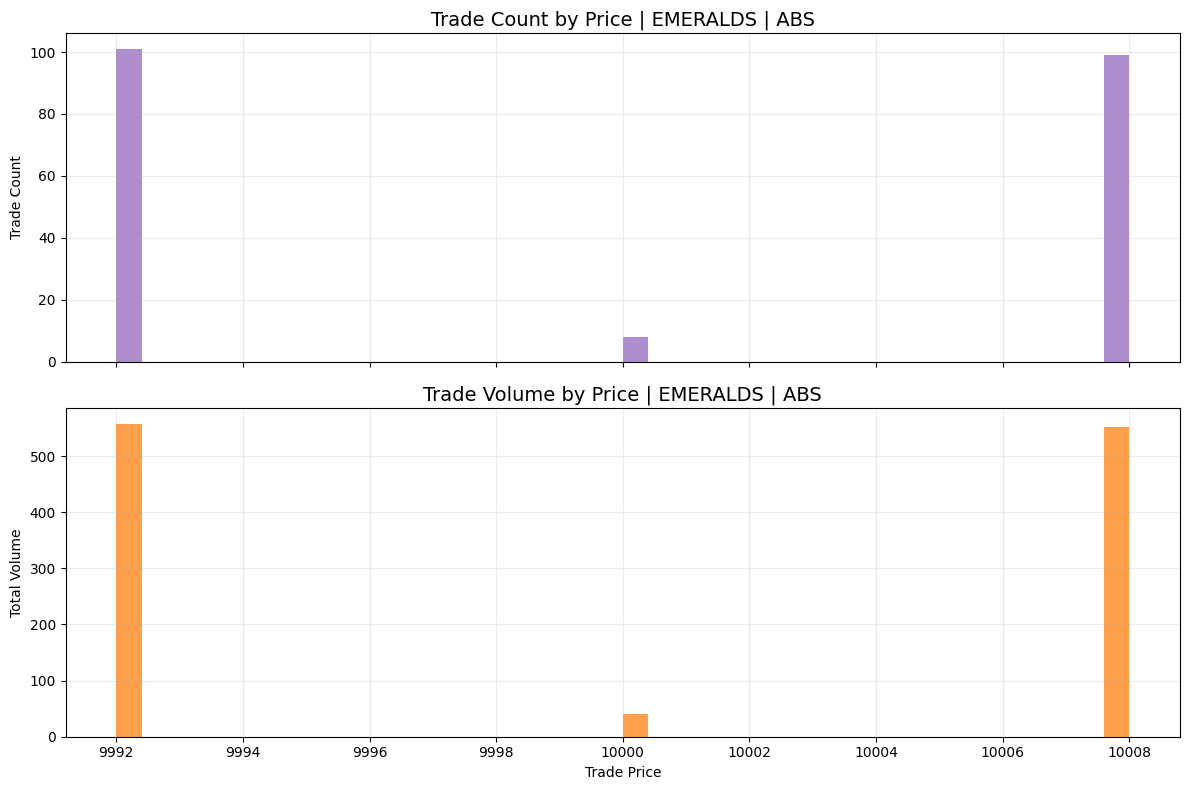

In [10]:
plot_trade_distribution("trades_round_0_day_-1.csv", symbol="EMERALDS", relative=False)

Day -2

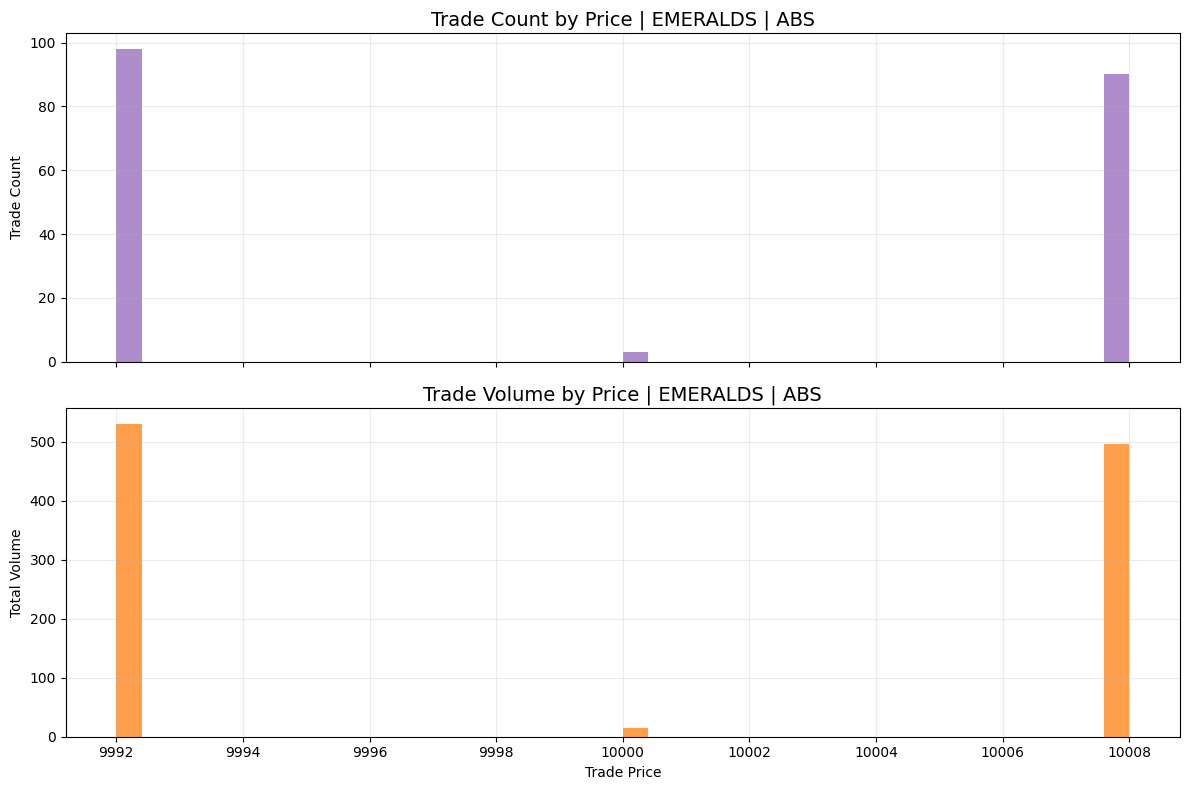

In [11]:
plot_trade_distribution("trades_round_0_day_-2.csv", symbol="EMERALDS", relative=False)

In [12]:
def plot_level_position_drift(
    trades_csv: str,
    symbol: str = "EMERALDS",
    buy_price: int = 9992,
    sell_price: int = 10008,
) -> pd.DataFrame:
    """
    Track and plot cumulative position drift from trades at two price levels.

    Rule:
      - +quantity for trades at buy_price
      - -quantity for trades at sell_price

    Returns a DataFrame indexed by timestamp with per-step and cumulative drift.
    """
    file_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(file_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(file_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required = {"timestamp", "symbol", "price", "quantity"}
    missing = required - set(trades.columns)
    if missing:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades = trades[trades["symbol"] == symbol.strip().upper()].copy()

    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades["quantity"] = pd.to_numeric(trades["quantity"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price", "quantity"])
    trades = trades[trades["quantity"] > 0].copy()

    if trades.empty:
        raise ValueError(f"No trades found for symbol={symbol} in {trades_csv}")

    trades["step_delta"] = 0
    trades.loc[trades["price"] == buy_price, "step_delta"] = trades.loc[trades["price"] == buy_price, "quantity"].astype(int)
    trades.loc[trades["price"] == sell_price, "step_delta"] = -trades.loc[trades["price"] == sell_price, "quantity"].astype(int)

    drift = (
        trades.groupby("timestamp", as_index=True)["step_delta"]
        .sum()
        .sort_index()
        .to_frame()
    )
    drift["cum_drift"] = drift["step_delta"].cumsum()

    plt.figure(figsize=(13, 5))
    plt.plot(drift.index, drift["cum_drift"], color="tab:blue", linewidth=2)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title(
        f"Position Drift from Level Trades | {symbol.upper()} | +{buy_price} / -{sell_price}",
        fontsize=14,
    )
    plt.xlabel("Timestamp")
    plt.ylabel("Cumulative Drift (qty)")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return drift


# Example usage:
# drift_day1 = plot_level_position_drift("trades_round_0_day_-1.csv", symbol="EMERALDS", buy_price=9992, sell_price=10008)
# drift_day2 = plot_level_position_drift("trades_round_0_day_-2.csv", symbol="EMERALDS", buy_price=9992, sell_price=10008)

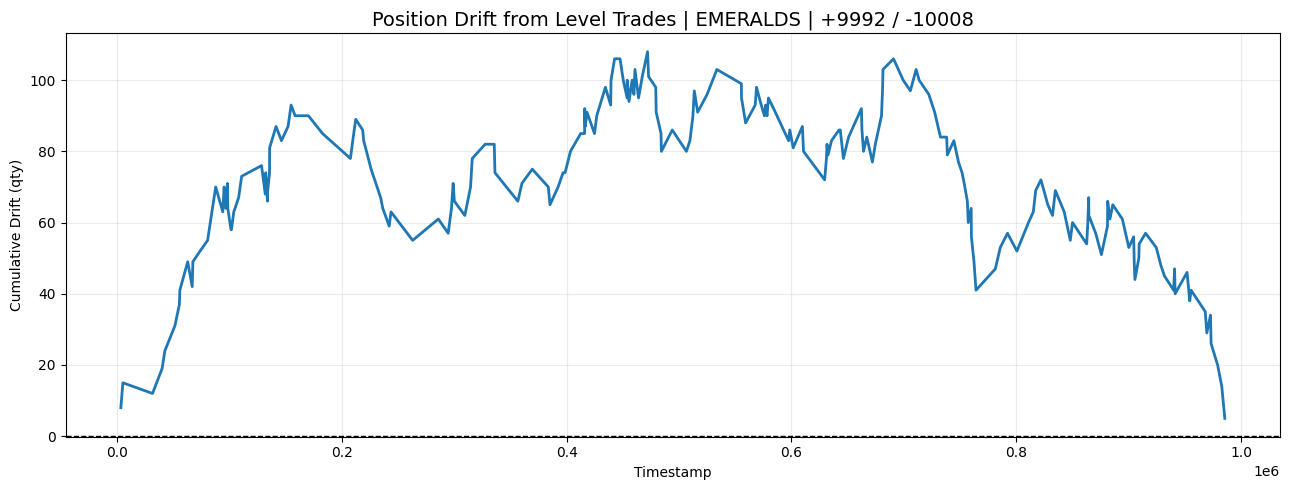

In [13]:
drift_day1 = plot_level_position_drift("trades_round_0_day_-1.csv", symbol="EMERALDS", buy_price=9992, sell_price=10008)


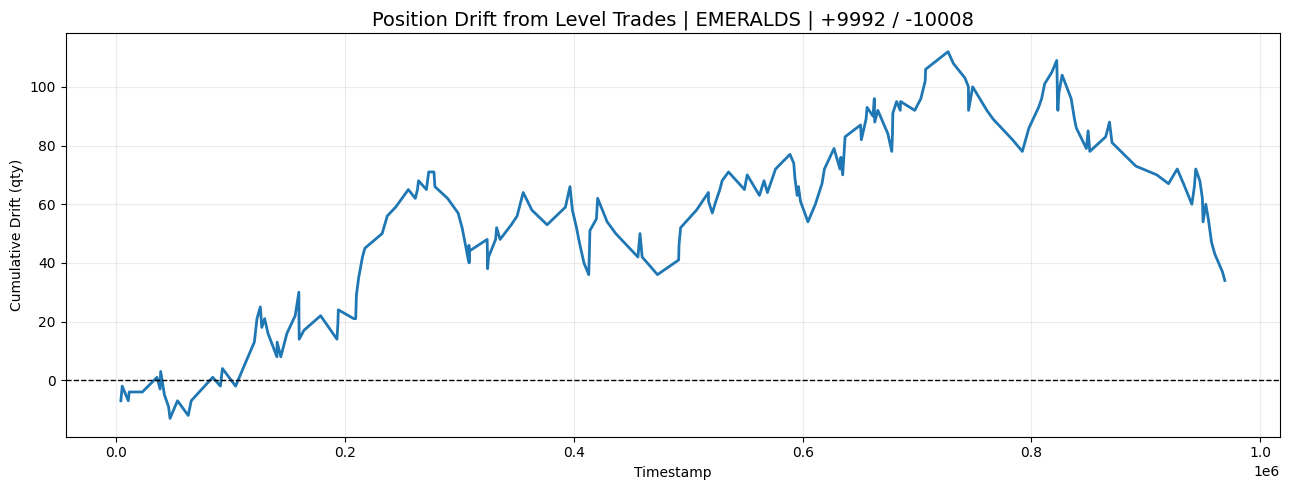

In [14]:
drift_day2 = plot_level_position_drift("trades_round_0_day_-2.csv", symbol="EMERALDS", buy_price=9992, sell_price=10008)

Tomato Analysis

In [15]:
def plot_midprice_movement_distribution(
    prices_csv: str,
    product: str = "TOMATOES",
    step: float = 0.5,
) -> pd.DataFrame:
    """
    Analyze and plot per-timestep mid_price movements.

    Movement is defined as:
      mid_move[t] = mid_price[t] - mid_price[t-1]

    The distribution is shown in relative movement buckets of `step` (default 0.5).
    """
    if step <= 0:
        raise ValueError("step must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    subset = df[df["product"] == asset].copy()

    if subset.empty:
        raise ValueError(f"No rows for product={asset} in file {prices_csv}")

    subset = (
        subset
        .dropna(subset=["timestamp", "mid_price"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
    )

    if len(subset) < 2:
        raise ValueError("Need at least two timestamps with mid_price to compute movement.")

    subset["mid_move"] = subset["mid_price"].diff()
    moves = subset["mid_move"].dropna()

    # Bucket moves into 0.5-style increments centered on those increments.
    bucketed = (moves / step).round() * step
    dist = bucketed.value_counts().sort_index().to_frame(name="count")
    dist["probability"] = dist["count"] / dist["count"].sum()

    plt.figure(figsize=(12, 5))
    plt.bar(dist.index, dist["count"], width=step * 0.9, color="tab:blue", alpha=0.8)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title(f"{asset} Mid-Price Movement Distribution (bucket={step})", fontsize=14)
    plt.xlabel("Relative Mid-Price Move per Timestep")
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    return dist


# Example usage:
# tomato_move_dist_day1 = plot_midprice_movement_distribution(
#     "prices_round_0_day_-1.csv",
#     product="TOMATOES",
#     step=0.5,
# )

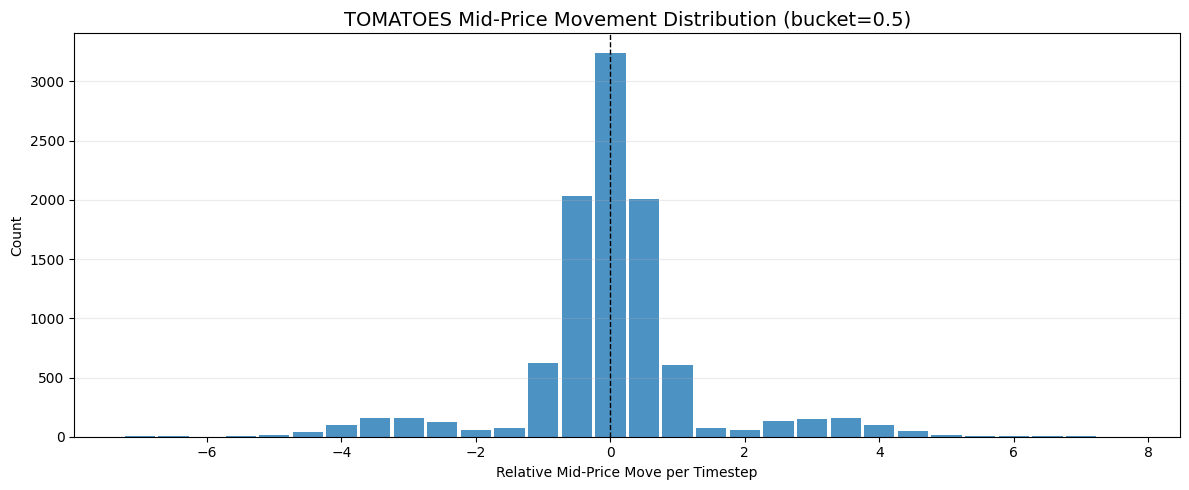

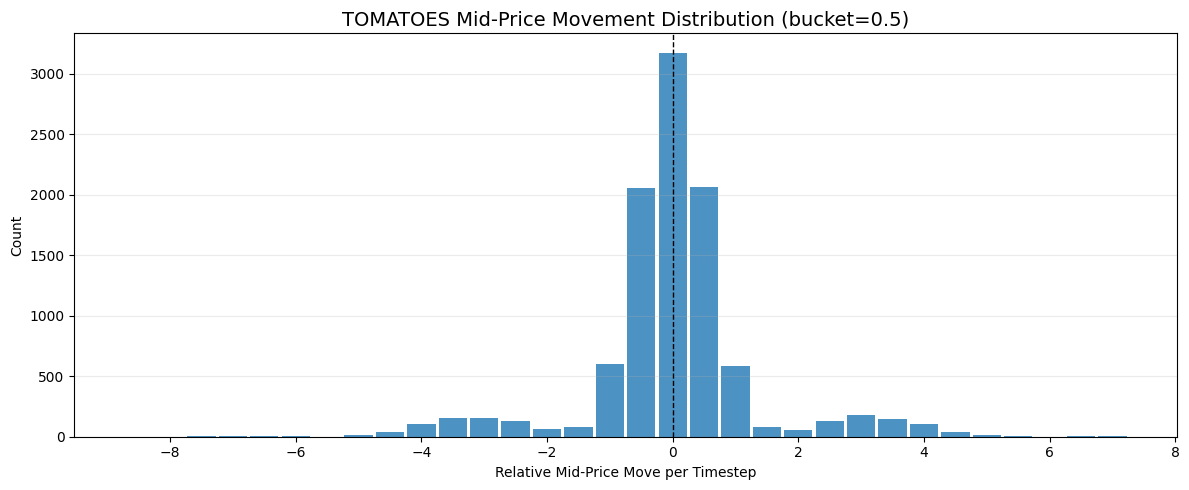

In [16]:
tomato_move_dist_day1 = plot_midprice_movement_distribution(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
    step=0.5,
)
tomato_move_dist_day1 = plot_midprice_movement_distribution(
    "prices_round_0_day_-2.csv",
    product="TOMATOES",
    step=0.5,
)

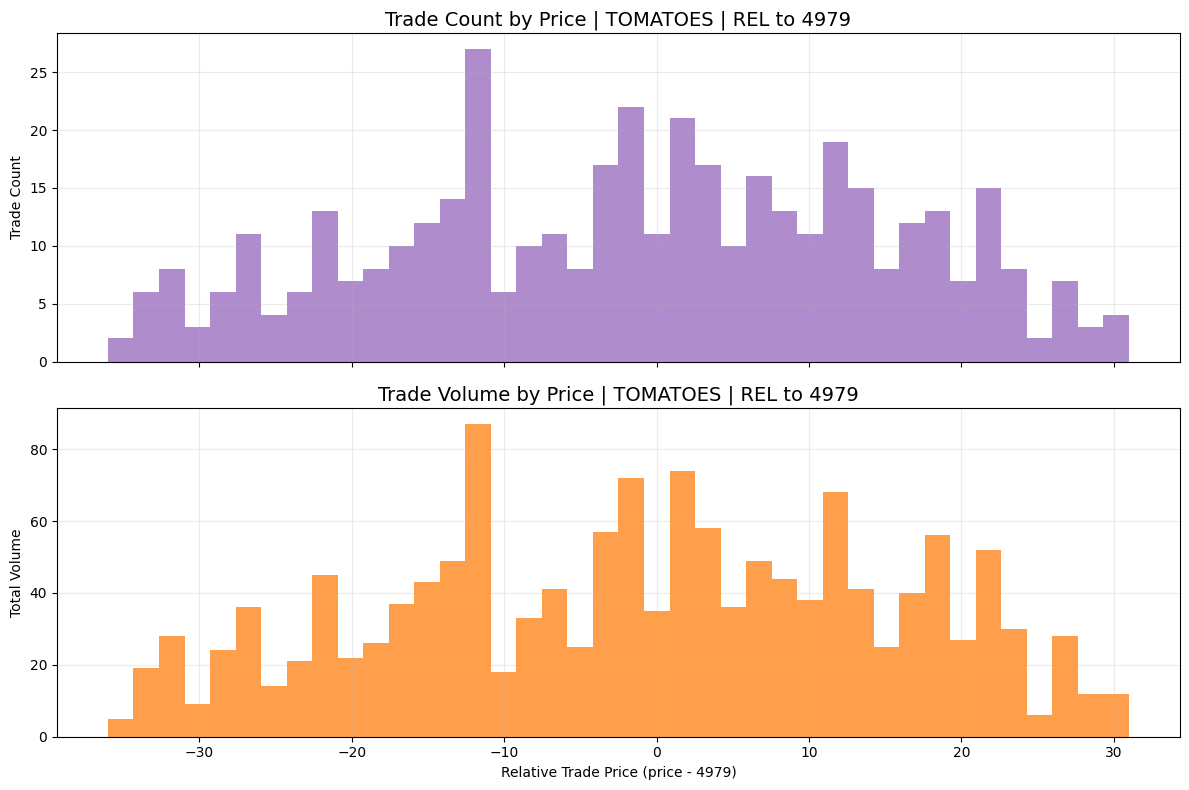

In [17]:
plot_trade_distribution("trades_round_0_day_-1.csv", symbol="TOMATOES", relative=True)

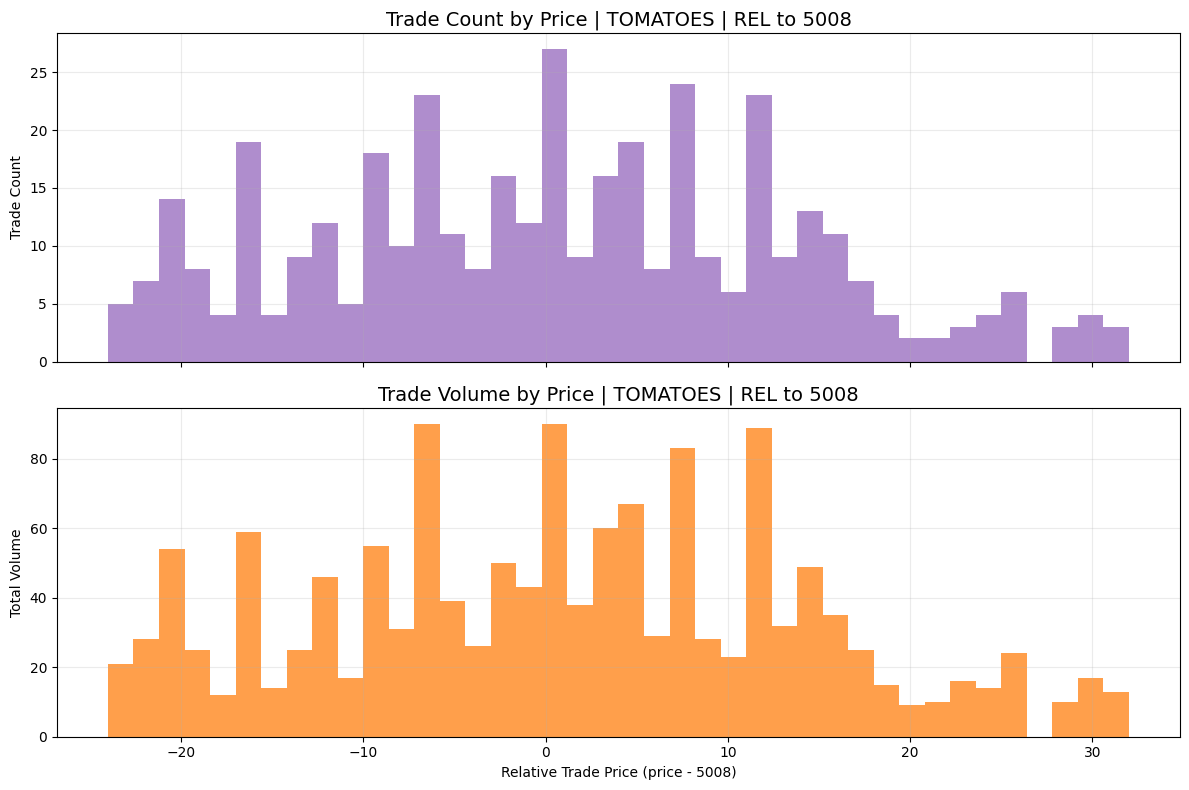

In [18]:
plot_trade_distribution("trades_round_0_day_-2.csv", symbol="TOMATOES", relative=True)


In [19]:
def plot_trade_distribution_vs_mid(
    trades_csv: str,
    prices_csv: str,
    symbol: str = "TOMATOES",
    bins: int = 40,
) -> pd.DataFrame:
    """
    Plot trade-price distribution relative to mid-price at each trade timestamp.

    Relative price is defined as:
      rel_price = trade_price - mid_price_at_trade_time

    Returns merged trade rows with columns including:
      timestamp, price, quantity, mid_price, rel_price
    """
    trades_path = resolve_data_path(trades_csv)
    prices_df = load_prices(prices_csv)

    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trades = {"timestamp", "symbol", "price", "quantity"}
    missing_trades = required_trades - set(trades.columns)
    if missing_trades:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trades)}")

    symbol_upper = symbol.strip().upper()

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades["quantity"] = pd.to_numeric(trades["quantity"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price", "quantity"])
    trades = trades[trades["symbol"] == symbol_upper].copy()
    trades = trades.sort_values("timestamp")

    mid = prices_df[prices_df["product"] == symbol_upper][["timestamp", "mid_price"]].copy()
    mid["timestamp"] = pd.to_numeric(mid["timestamp"], errors="coerce")
    mid["mid_price"] = pd.to_numeric(mid["mid_price"], errors="coerce")
    mid = (
        mid.dropna(subset=["timestamp", "mid_price"])
           .drop_duplicates(subset=["timestamp"], keep="last")
           .sort_values("timestamp")
    )

    if trades.empty:
        raise ValueError(f"No trades found for symbol={symbol_upper} in {trades_csv}")
    if mid.empty:
        raise ValueError(f"No mid_price rows found for symbol={symbol_upper} in {prices_csv}")

    merged = pd.merge_asof(
        trades,
        mid,
        on="timestamp",
        direction="backward",
    )
    merged = merged.dropna(subset=["mid_price"]).copy()

    if merged.empty:
        raise ValueError("No trades could be matched to a mid_price timestamp.")

    merged["rel_price"] = merged["price"] - merged["mid_price"]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].hist(merged["rel_price"], bins=bins, color="tab:purple", alpha=0.75)
    axes[0].set_title(f"Trade Count by Relative Price vs Mid | {symbol_upper}", fontsize=14)
    axes[0].set_ylabel("Trade Count")
    axes[0].grid(alpha=0.25)
    axes[0].axvline(0, color="black", linestyle="--", linewidth=1)

    axes[1].hist(
        merged["rel_price"],
        bins=bins,
        weights=merged["quantity"],
        color="tab:orange",
        alpha=0.75,
    )
    axes[1].set_title(f"Trade Volume by Relative Price vs Mid | {symbol_upper}", fontsize=14)
    axes[1].set_xlabel("Relative Trade Price (trade - mid_price)")
    axes[1].set_ylabel("Total Volume")
    axes[1].grid(alpha=0.25)
    axes[1].axvline(0, color="black", linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()

    return merged[["timestamp", "price", "quantity", "mid_price", "rel_price"]].copy()


# Example usage:
# tomato_rel_day1 = plot_trade_distribution_vs_mid(
#     "trades_round_0_day_-1.csv",
#     "prices_round_0_day_-1.csv",
#     symbol="TOMATOES",
# )

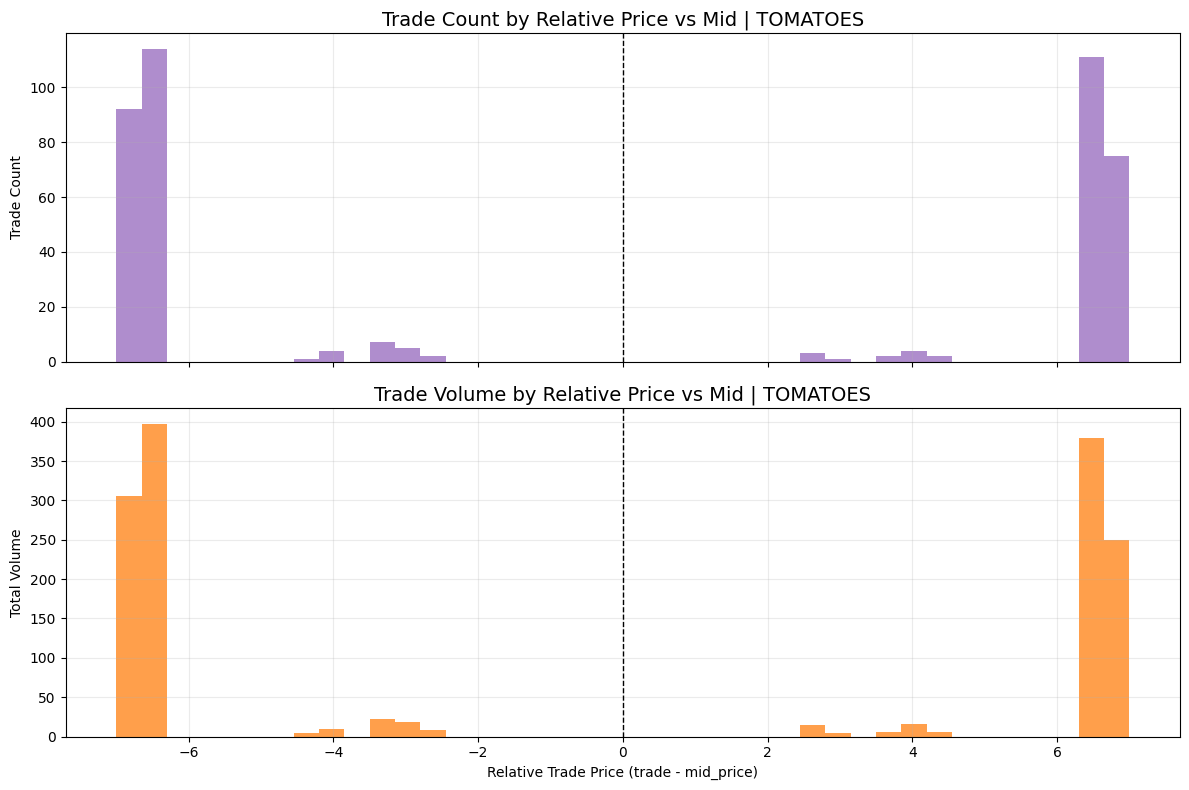

In [20]:
tomato_rel_day1 = plot_trade_distribution_vs_mid(
    "trades_round_0_day_-1.csv",
    "prices_round_0_day_-1.csv",
    symbol="TOMATOES",
)

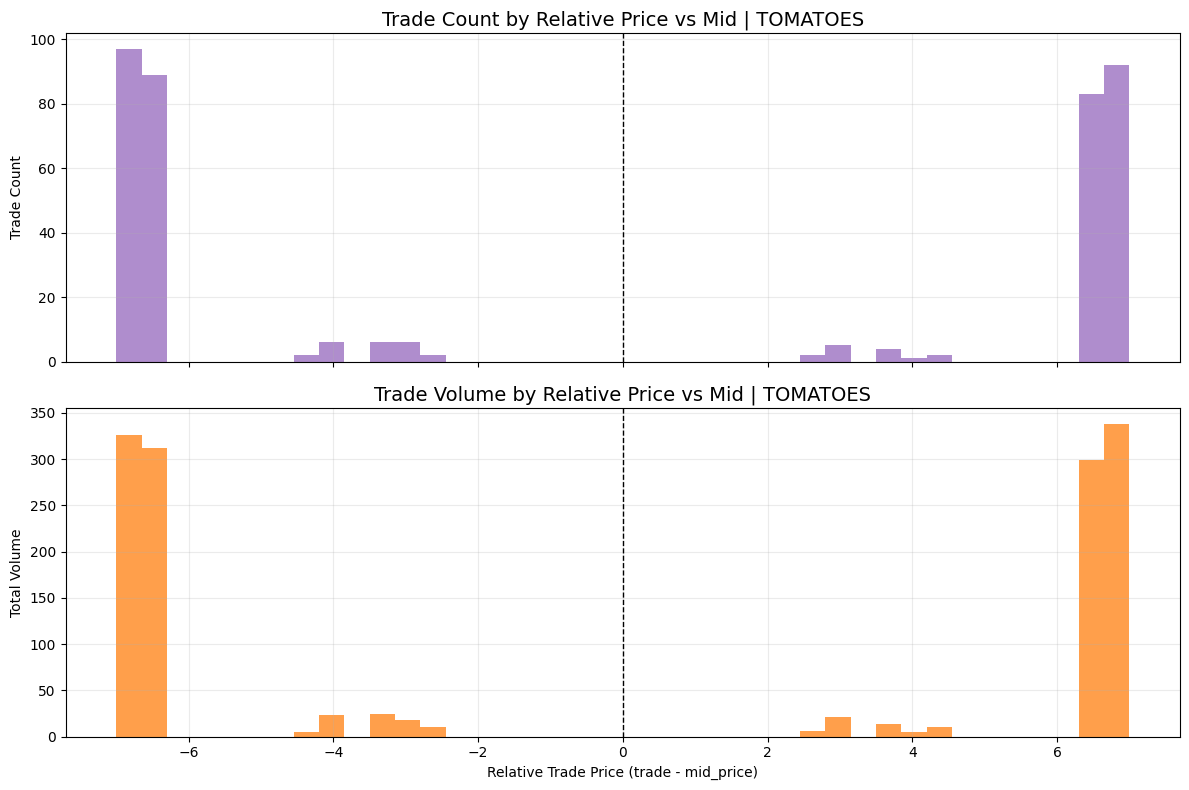

In [21]:
tomato_rel_day2 = plot_trade_distribution_vs_mid(
    "trades_round_0_day_-2.csv",
    "prices_round_0_day_-2.csv",
    symbol="TOMATOES",
)

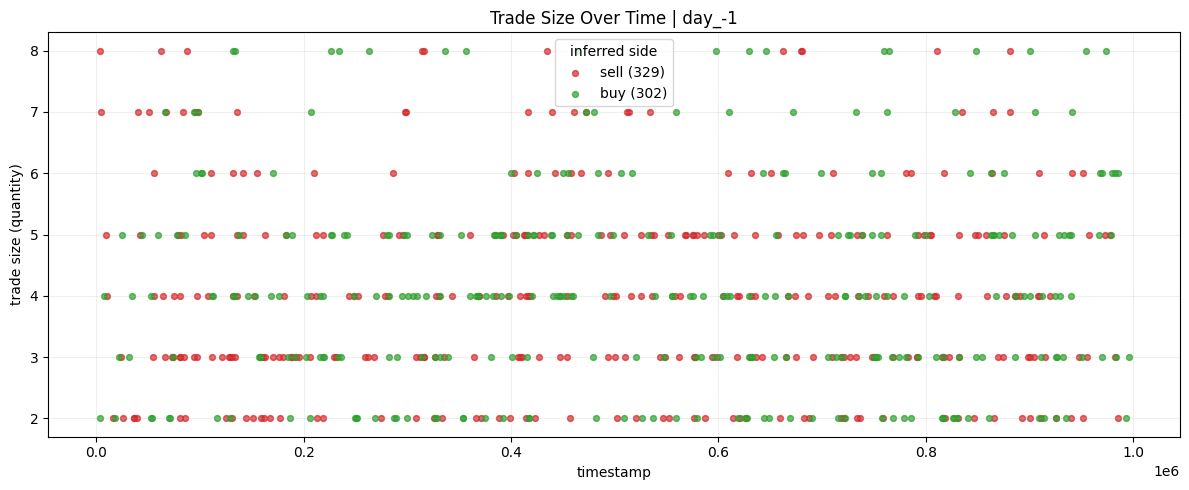

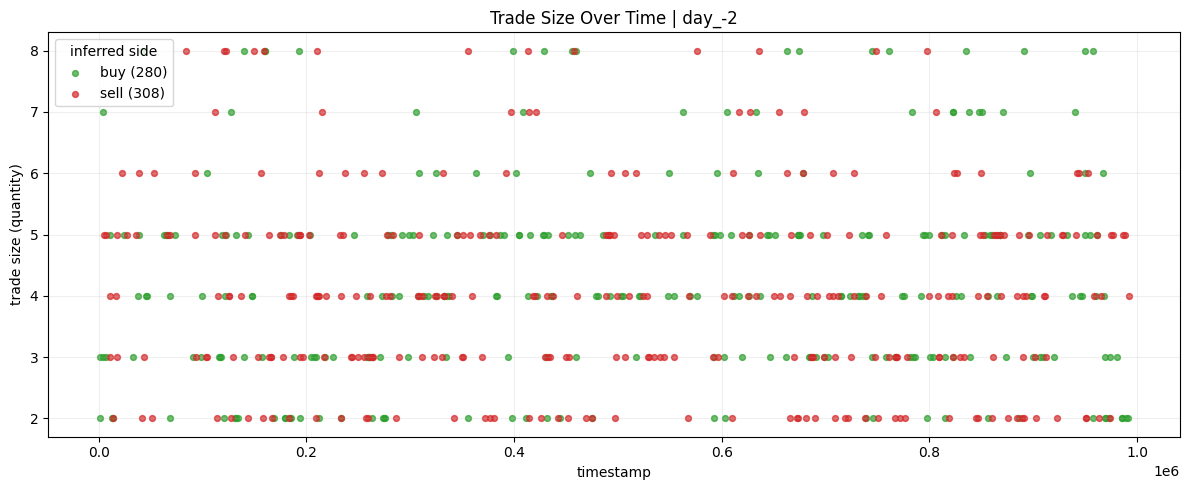

Loaded trade/price file pairs:
- trades_round_0_day_-1.csv  <->  prices_round_0_day_-1.csv
- trades_round_0_day_-2.csv  <->  prices_round_0_day_-2.csv
Total rows plotted: 1219


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re


def day_from_name(name: str):
    m = re.search(r"day_(-?\d+)", name)
    return int(m.group(1)) if m else None


# Pick day -1 and one day-2 variant.
trade_candidates = [
    "trades_round_0_day_-1.csv",
    "trades_round_0_day_-2.csv",
    "trades_round_0_day_02.csv",
]

selected_trade_files = []
for f in trade_candidates:
    if Path(f).exists():
        selected_trade_files.append(f)

selected = []
if "trades_round_0_day_-1.csv" in selected_trade_files:
    selected.append("trades_round_0_day_-1.csv")
if "trades_round_0_day_-2.csv" in selected_trade_files:
    selected.append("trades_round_0_day_-2.csv")
elif "trades_round_0_day_02.csv" in selected_trade_files:
    selected.append("trades_round_0_day_02.csv")

if len(selected) < 2:
    raise FileNotFoundError(
        "Expected trades_round_0_day_-1.csv and either trades_round_0_day_-2.csv or trades_round_0_day_02.csv."
    )

all_rows = []
loaded_pairs = []

for tf in selected:
    day = day_from_name(tf)
    price_options = [
        f"prices_round_0_day_{day}.csv",
        f"prices_round_0_day_{str(day).zfill(2)}.csv" if day is not None and day >= 0 else None,
    ]
    price_options = [p for p in price_options if p is not None]

    pf = None
    for p in price_options:
        if Path(p).exists():
            pf = p
            break

    if pf is None:
        print(f"Skipping {tf}: matching prices file not found.")
        continue

    trades = pd.read_csv(tf, sep=";")
    prices = pd.read_csv(pf, sep=";")

    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["quantity"] = pd.to_numeric(trades["quantity"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")

    prices["timestamp"] = pd.to_numeric(prices["timestamp"], errors="coerce")
    prices["mid_price"] = pd.to_numeric(prices["mid_price"], errors="coerce")

    prices = prices[["timestamp", "product", "mid_price"]].rename(columns={"product": "symbol"})

    m = trades.merge(prices, on=["timestamp", "symbol"], how="left")
    m = m.dropna(subset=["timestamp", "quantity", "price"])

    # Infer direction from relative trade price.
    m["side"] = np.select(
        [m["price"] > m["mid_price"], m["price"] < m["mid_price"]],
        ["buy", "sell"],
        default="flat_or_unknown",
    )

    m["day_label"] = tf.replace("trades_round_0_", "").replace(".csv", "")
    all_rows.append(m[["timestamp", "quantity", "side", "day_label", "symbol"]])
    loaded_pairs.append((tf, pf))

if not all_rows:
    raise ValueError("No trade rows available to plot after loading files.")

plot_df = pd.concat(all_rows, ignore_index=True)
plot_df = plot_df.sort_values(["day_label", "timestamp"]).reset_index(drop=True)

colors = {
    "buy": "tab:green",
    "sell": "tab:red",
    "flat_or_unknown": "tab:gray",
}

for day, gday in plot_df.groupby("day_label", sort=True):
    plt.figure(figsize=(12, 5))
    for side, gside in gday.groupby("side", sort=False):
        plt.scatter(
            gside["timestamp"],
            gside["quantity"],
            s=18,
            alpha=0.7,
            color=colors.get(side, "tab:blue"),
            label=f"{side} ({len(gside)})",
        )

    plt.title(f"Trade Size Over Time | {day}")
    plt.xlabel("timestamp")
    plt.ylabel("trade size (quantity)")
    plt.legend(title="inferred side")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

print("Loaded trade/price file pairs:")
for tf, pf in loaded_pairs:
    print(f"- {tf}  <->  {pf}")
print("Total rows plotted:", len(plot_df))

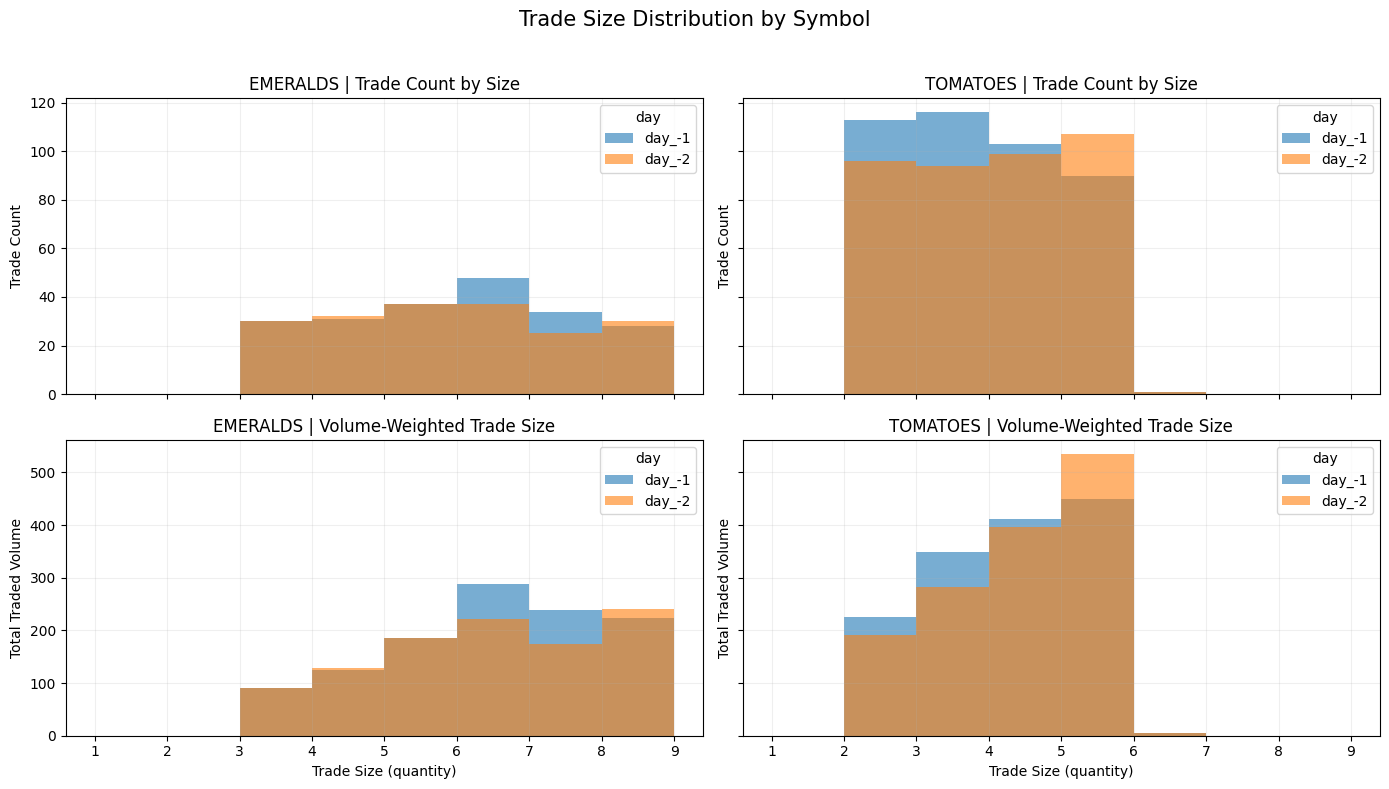

Loaded files:
- trades_round_0_day_-1.csv
- trades_round_0_day_-2.csv
Rows used: 1219

Trade counts by symbol and day:
symbol    day   
EMERALDS  day_-1    208
          day_-2    191
TOMATOES  day_-1    423
          day_-2    397
dtype: int64


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Trade size distribution broken down by symbol and day.
trade_candidates = [
    "trades_round_0_day_-1.csv",
    "trades_round_0_day_-2.csv",
    "trades_round_0_day_02.csv",
]

selected = []
if Path("trades_round_0_day_-1.csv").exists():
    selected.append("trades_round_0_day_-1.csv")
if Path("trades_round_0_day_-2.csv").exists():
    selected.append("trades_round_0_day_-2.csv")
elif Path("trades_round_0_day_02.csv").exists():
    selected.append("trades_round_0_day_02.csv")

if len(selected) < 2:
    raise FileNotFoundError(
        "Expected trades_round_0_day_-1.csv and either trades_round_0_day_-2.csv or trades_round_0_day_02.csv."
    )

frames = []
for f in selected:
    df = pd.read_csv(f, sep=";")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df = df.dropna(subset=["quantity"])
    df = df[df["quantity"] > 0].copy()
    df["day"] = f.replace("trades_round_0_", "").replace(".csv", "")
    df["symbol"] = df["symbol"].astype(str).str.strip().str.upper()
    frames.append(df[["quantity", "day", "symbol"]])

trade_sizes = pd.concat(frames, ignore_index=True)
trade_sizes = trade_sizes[trade_sizes["symbol"].isin(["EMERALDS", "TOMATOES"])].copy()

symbols = ["EMERALDS", "TOMATOES"]
days = list(trade_sizes["day"].dropna().unique())
days = sorted(days)

max_q = int(trade_sizes["quantity"].max())
bins = range(1, max_q + 2)
colors = {days[0]: "tab:blue" if len(days) > 0 else "tab:blue"}
if len(days) > 1:
    colors[days[1]] = "tab:orange"
if len(days) > 2:
    extra_colors = ["tab:green", "tab:red", "tab:purple", "tab:brown"]
    for idx, day in enumerate(days[2:]):
        colors[day] = extra_colors[idx % len(extra_colors)]

fig, axes = plt.subplots(2, len(symbols), figsize=(14, 8), sharex=True, sharey="row")
if len(symbols) == 1:
    axes = axes.reshape(2, 1)

for col, symbol in enumerate(symbols):
    subset_symbol = trade_sizes[trade_sizes["symbol"] == symbol]

    # Count histogram
    ax_count = axes[0, col]
    for day, g in subset_symbol.groupby("day", sort=True):
        ax_count.hist(
            g["quantity"],
            bins=bins,
            alpha=0.6,
            label=day,
            color=colors.get(day, None),
        )
    ax_count.set_title(f"{symbol} | Trade Count by Size")
    ax_count.set_ylabel("Trade Count")
    ax_count.grid(alpha=0.2)
    ax_count.legend(title="day")

    # Volume-weighted histogram
    ax_vol = axes[1, col]
    for day, g in subset_symbol.groupby("day", sort=True):
        ax_vol.hist(
            g["quantity"],
            bins=bins,
            weights=g["quantity"],
            alpha=0.6,
            label=day,
            color=colors.get(day, None),
        )
    ax_vol.set_title(f"{symbol} | Volume-Weighted Trade Size")
    ax_vol.set_xlabel("Trade Size (quantity)")
    ax_vol.set_ylabel("Total Traded Volume")
    ax_vol.grid(alpha=0.2)
    ax_vol.legend(title="day")

plt.suptitle("Trade Size Distribution by Symbol", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Loaded files:")
for f in selected:
    print("-", f)
print("Rows used:", len(trade_sizes))
print("\nTrade counts by symbol and day:")
print(trade_sizes.groupby(["symbol", "day"]).size())

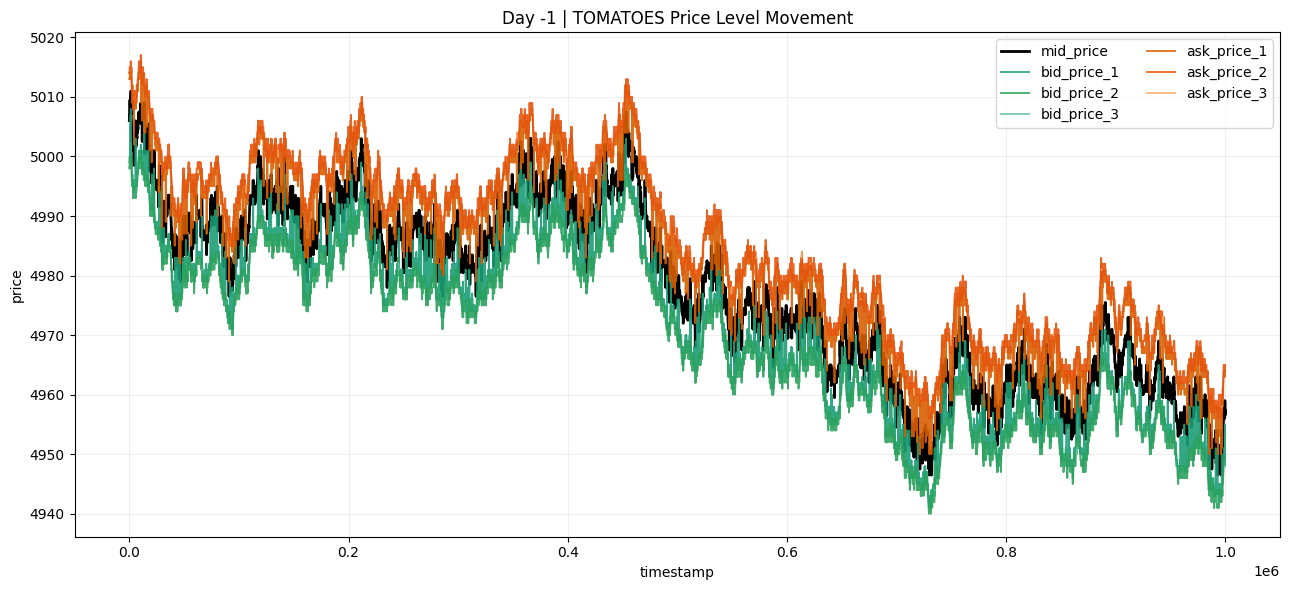

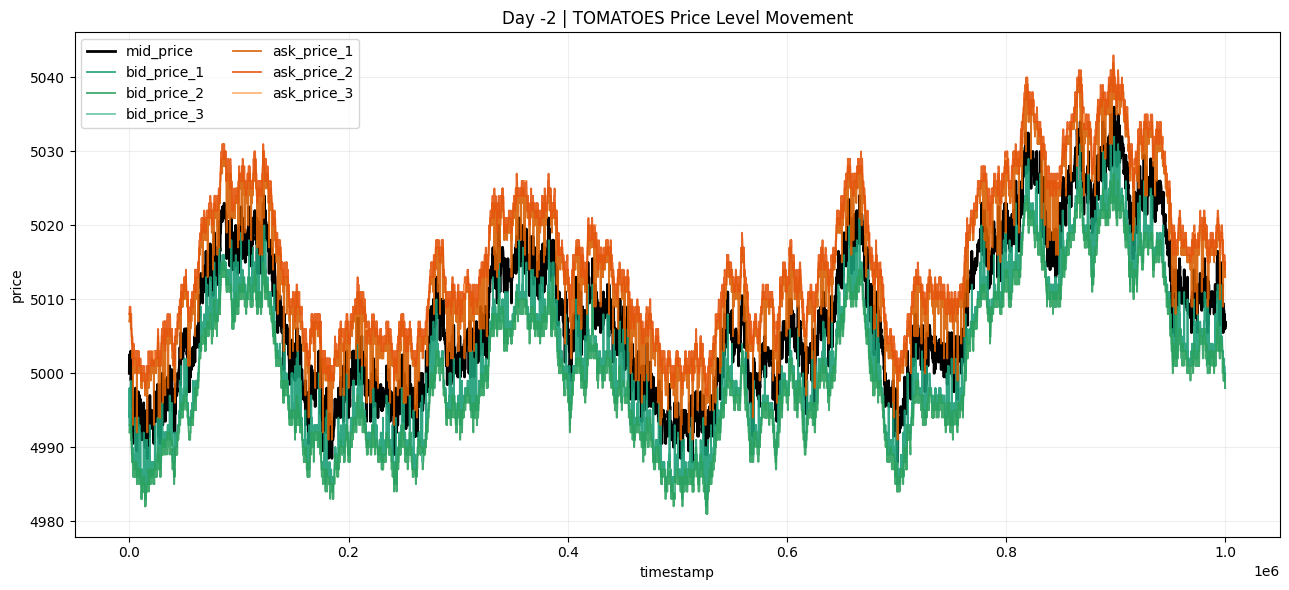

In [24]:
def plot_tomato_price_levels(prices_csv: str, title_prefix: str | None = None) -> pd.DataFrame:
    """Plot TOMATOES mid_price, bid prices, and ask prices over time."""
    prices_tom = load_prices(prices_csv)
    prices_tom = prices_tom[prices_tom["product"] == "TOMATOES"].copy()

    if prices_tom.empty:
        raise ValueError(f"No TOMATOES rows found in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]

    for c in cols:
        if c in prices_tom.columns:
            prices_tom[c] = pd.to_numeric(prices_tom[c], errors="coerce")

    prices_tom = (
        prices_tom[cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
    )

    plt.figure(figsize=(13, 6))

    plt.plot(
        prices_tom["timestamp"],
        prices_tom["mid_price"],
        color="black",
        linewidth=2.0,
        label="mid_price",
    )

    bid_colors = ["#1b9e77", "#2ca25f", "#66c2a4"]
    for i, col in enumerate(["bid_price_1", "bid_price_2", "bid_price_3"]):
        plt.plot(
            prices_tom["timestamp"],
            prices_tom[col],
            color=bid_colors[i],
            linewidth=1.3,
            alpha=0.9,
            label=col,
        )

    ask_colors = ["#d95f02", "#e6550d", "#fdae6b"]
    for i, col in enumerate(["ask_price_1", "ask_price_2", "ask_price_3"]):
        plt.plot(
            prices_tom["timestamp"],
            prices_tom[col],
            color=ask_colors[i],
            linewidth=1.3,
            alpha=0.9,
            label=col,
        )

    title = "TOMATOES Price Level Movement"
    if title_prefix:
        title = f"{title_prefix} | {title}"

    plt.title(title)
    plt.xlabel("timestamp")
    plt.ylabel("price")
    plt.grid(alpha=0.2)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    return prices_tom


prices_tom_day1 = plot_tomato_price_levels(
    "prices_round_0_day_-1.csv",
    title_prefix="Day -1",
)

prices_tom_day2 = plot_tomato_price_levels(
    "prices_round_0_day_-2.csv",
    title_prefix="Day -2",
)

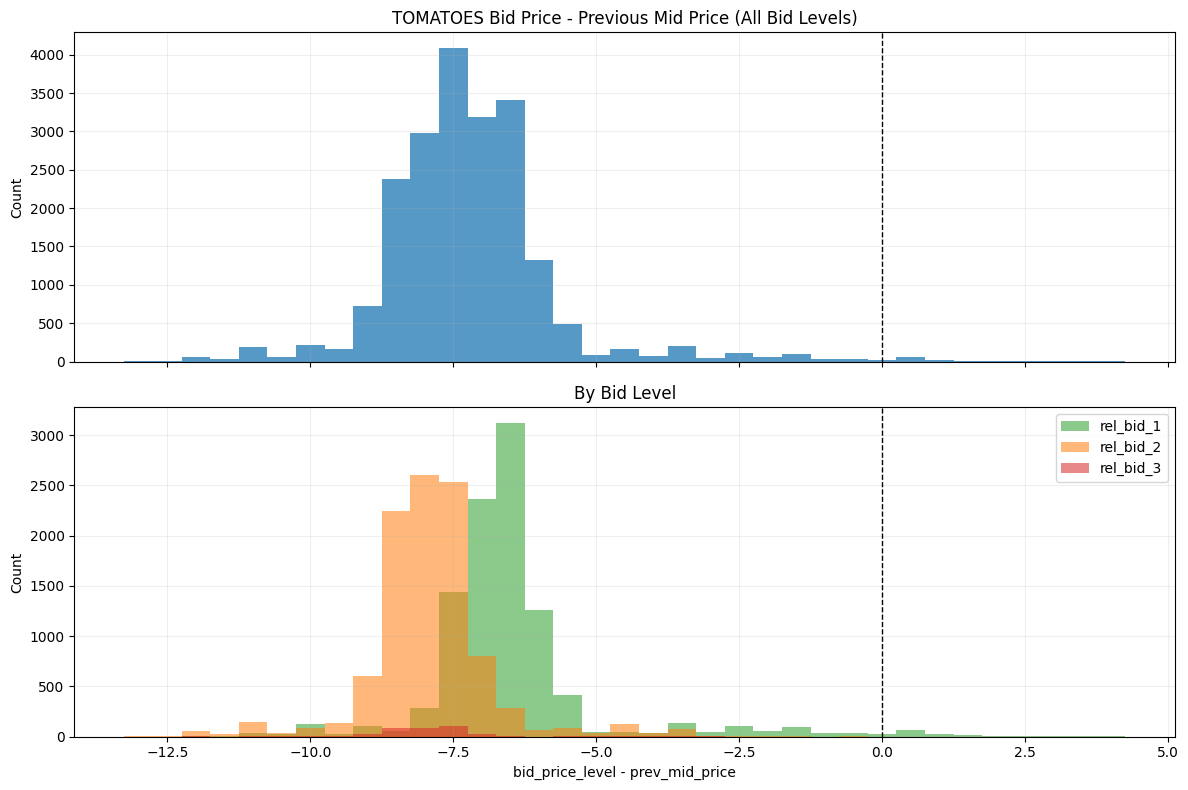

File: prices_round_0_day_-1.csv
Rows used (after shift): 9999
rel_bid_1: mean=-6.492, std=1.542, n=9999
rel_bid_2: mean=-7.905, std=1.091, n=9999
rel_bid_3: mean=-8.007, std=1.079, n=367


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Distribution of TOMATOES bid prices relative to previous timestamp mid-price.
file_path = "prices_round_0_day_-1.csv"
product = "TOMATOES"

df = load_prices(file_path)
sub = df[df["product"] == product].copy()

if sub.empty:
    raise ValueError(f"No rows found for product={product} in {file_path}")

cols = [
    "timestamp", "mid_price",
    "bid_price_1", "bid_price_2", "bid_price_3",
]

for c in cols:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

sub = (
    sub[cols]
    .dropna(subset=["timestamp", "mid_price"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
)

# Previous timestamp midpoint for each row
sub["prev_mid_price"] = sub["mid_price"].shift(1)

# Relative bid prices to previous midpoint
for lvl in [1, 2, 3]:
    sub[f"rel_bid_{lvl}"] = sub[f"bid_price_{lvl}"] - sub["prev_mid_price"]

plot_cols = ["rel_bid_1", "rel_bid_2", "rel_bid_3"]
all_rel = pd.concat([sub[c] for c in plot_cols], ignore_index=True).dropna()

if all_rel.empty:
    raise ValueError("No relative bid values available after alignment to previous midpoint.")

# Use 0.5-grid bins for cleaner visualization
min_x = np.floor(all_rel.min() * 2) / 2 - 0.25
max_x = np.ceil(all_rel.max() * 2) / 2 + 0.25
bins = np.arange(min_x, max_x + 0.5, 0.5)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Overall distribution
axes[0].hist(all_rel, bins=bins, color="tab:blue", alpha=0.75)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("TOMATOES Bid Price - Previous Mid Price (All Bid Levels)")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2)

# Per-level overlay
colors = {"rel_bid_1": "tab:green", "rel_bid_2": "tab:orange", "rel_bid_3": "tab:red"}
for c in plot_cols:
    vals = sub[c].dropna()
    if len(vals) > 0:
        axes[1].hist(vals, bins=bins, alpha=0.55, label=c, color=colors[c])

axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("By Bid Level")
axes[1].set_xlabel("bid_price_level - prev_mid_price")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"File: {file_path}")
print(f"Rows used (after shift): {sub['prev_mid_price'].notna().sum()}")
for c in plot_cols:
    vals = sub[c].dropna()
    if len(vals) > 0:
        print(f"{c}: mean={vals.mean():.3f}, std={vals.std(ddof=1):.3f}, n={len(vals)}")

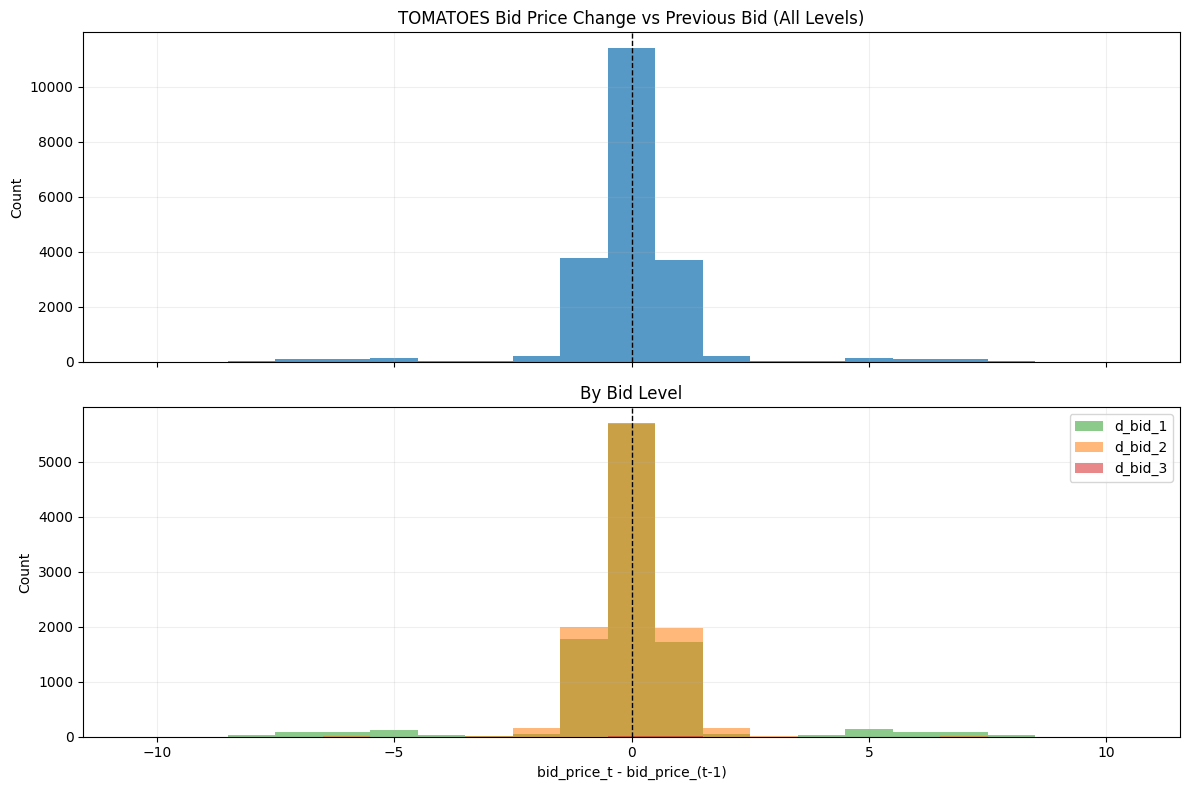

File: prices_round_0_day_-1.csv
Rows used (after lag): 9999
d_bid_1: mean=-0.005, std=1.716, n=9999
d_bid_2: mean=-0.005, std=0.750, n=9999
d_bid_3: mean=0.105, std=0.459, n=19


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Distribution of TOMATOES bid price changes vs previous timestamp's bid price.
file_path = "prices_round_0_day_-1.csv"
product = "TOMATOES"

df = load_prices(file_path)
sub = df[df["product"] == product].copy()

if sub.empty:
    raise ValueError(f"No rows found for product={product} in {file_path}")

cols = ["timestamp", "bid_price_1", "bid_price_2", "bid_price_3"]
for c in cols:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

sub = (
    sub[cols]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
)

# First differences by bid level
for lvl in [1, 2, 3]:
    sub[f"d_bid_{lvl}"] = sub[f"bid_price_{lvl}"] - sub[f"bid_price_{lvl}"].shift(1)

plot_cols = ["d_bid_1", "d_bid_2", "d_bid_3"]
all_diff = pd.concat([sub[c] for c in plot_cols], ignore_index=True).dropna()

if all_diff.empty:
    raise ValueError("No bid differences available after lag alignment.")

# Use 1-tick bins centered on integer deltas
min_x = int(np.floor(all_diff.min())) - 1
max_x = int(np.ceil(all_diff.max())) + 1
bins = np.arange(min_x - 0.5, max_x + 1.5, 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Overall across all bid levels
axes[0].hist(all_diff, bins=bins, color="tab:blue", alpha=0.75)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("TOMATOES Bid Price Change vs Previous Bid (All Levels)")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2)

# Per-level overlay
colors = {"d_bid_1": "tab:green", "d_bid_2": "tab:orange", "d_bid_3": "tab:red"}
for c in plot_cols:
    vals = sub[c].dropna()
    if len(vals) > 0:
        axes[1].hist(vals, bins=bins, alpha=0.55, label=c, color=colors[c])

axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("By Bid Level")
axes[1].set_xlabel("bid_price_t - bid_price_(t-1)")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"File: {file_path}")
print(f"Rows used (after lag): {len(sub) - 1}")
for c in plot_cols:
    vals = sub[c].dropna()
    if len(vals) > 0:
        print(f"{c}: mean={vals.mean():.3f}, std={vals.std(ddof=1):.3f}, n={len(vals)}")

In [27]:
def plot_tomato_position_drift_mid(
    trades_csv: str = "trades_round_0_day_-1.csv",
    prices_csv: str = "prices_round_0_day_-1.csv",
    symbol: str = "TOMATOES",
) -> pd.DataFrame:
    """
    Track and plot cumulative position drift for TOMATOES using the mid_price
    from the matching prices file as the reference.

    Rule:
      - +quantity when trade_price > mid_price
      - -quantity when trade_price < mid_price
      - 0 when trade_price == mid_price or mid_price is missing

    Returns a DataFrame indexed by timestamp with per-step drift and cumulative drift.
    """
    trades_path = resolve_data_path(trades_csv)
    prices_path = resolve_data_path(prices_csv)

    trades_df = pd.read_csv(trades_path, sep=";", engine="python")
    prices_df = pd.read_csv(prices_path, sep=";", engine="python")

    trades_df.columns = [str(c).strip().lower() for c in trades_df.columns]
    prices_df.columns = [str(c).strip().lower() for c in prices_df.columns]

    required_trades = {"timestamp", "symbol", "price", "quantity"}
    required_prices = {"timestamp", "product", "mid_price"}
    missing_trades = required_trades - set(trades_df.columns)
    missing_prices = required_prices - set(prices_df.columns)
    if missing_trades:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trades)}")
    if missing_prices:
        raise ValueError(f"Missing required columns in prices CSV: {sorted(missing_prices)}")

    trades_df["symbol"] = trades_df["symbol"].astype(str).str.strip().str.upper()
    prices_df["product"] = prices_df["product"].astype(str).str.strip().str.upper()

    trades_df["timestamp"] = pd.to_numeric(trades_df["timestamp"], errors="coerce")
    trades_df["price"] = pd.to_numeric(trades_df["price"], errors="coerce")
    trades_df["quantity"] = pd.to_numeric(trades_df["quantity"], errors="coerce")
    prices_df["timestamp"] = pd.to_numeric(prices_df["timestamp"], errors="coerce")
    prices_df["mid_price"] = pd.to_numeric(prices_df["mid_price"], errors="coerce")

    trade_side = trades_df[trades_df["symbol"] == symbol.strip().upper()].copy()
    price_side = prices_df[prices_df["product"] == symbol.strip().upper()][["timestamp", "product", "mid_price"]].copy()
    price_side = price_side.rename(columns={"product": "symbol"})

    trade_side = trade_side.dropna(subset=["timestamp", "price", "quantity"])
    price_side = price_side.dropna(subset=["timestamp", "mid_price"])

    if trade_side.empty:
        raise ValueError(f"No trades found for symbol={symbol} in {trades_csv}")
    if price_side.empty:
        raise ValueError(f"No price rows found for symbol={symbol} in {prices_csv}")

    merged = trade_side.merge(price_side, on=["timestamp", "symbol"], how="left")
    merged = merged.sort_values("timestamp")

    merged["step_delta"] = 0
    merged.loc[merged["price"] > merged["mid_price"], "step_delta"] = merged.loc[
        merged["price"] > merged["mid_price"], "quantity"
    ].astype(int)
    merged.loc[merged["price"] < merged["mid_price"], "step_delta"] = -merged.loc[
        merged["price"] < merged["mid_price"], "quantity"
    ].astype(int)

    drift = (
        merged.groupby("timestamp", as_index=True)["step_delta"]
        .sum()
        .sort_index()
        .to_frame()
    )
    drift["cum_drift"] = drift["step_delta"].cumsum()

    plt.figure(figsize=(13, 5))
    plt.plot(drift.index, drift["cum_drift"], color="tab:blue", linewidth=2)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title(f"Position Drift from Mid-Referenced TOMATO Trades | {symbol.upper()}", fontsize=14)
    plt.xlabel("Timestamp")
    plt.ylabel("Cumulative Drift (qty)")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"Trades file: {trades_csv}")
    print(f"Prices file: {prices_csv}")
    print(f"Total trades used: {len(merged)}")
    print(f"Positive drift steps: {(drift['step_delta'] > 0).sum()}")
    print(f"Negative drift steps: {(drift['step_delta'] < 0).sum()}")

    return drift


# Example usage:
# tomato_mid_drift_day1 = plot_tomato_position_drift_mid(
#     "trades_round_0_day_-1.csv",
#     "prices_round_0_day_-1.csv",
#     symbol="TOMATOES",
# )
# tomato_mid_drift_day2 = plot_tomato_position_drift_mid(
#     "trades_round_0_day_-2.csv",
#     "prices_round_0_day_-2.csv",
#     symbol="TOMATOES",
# )

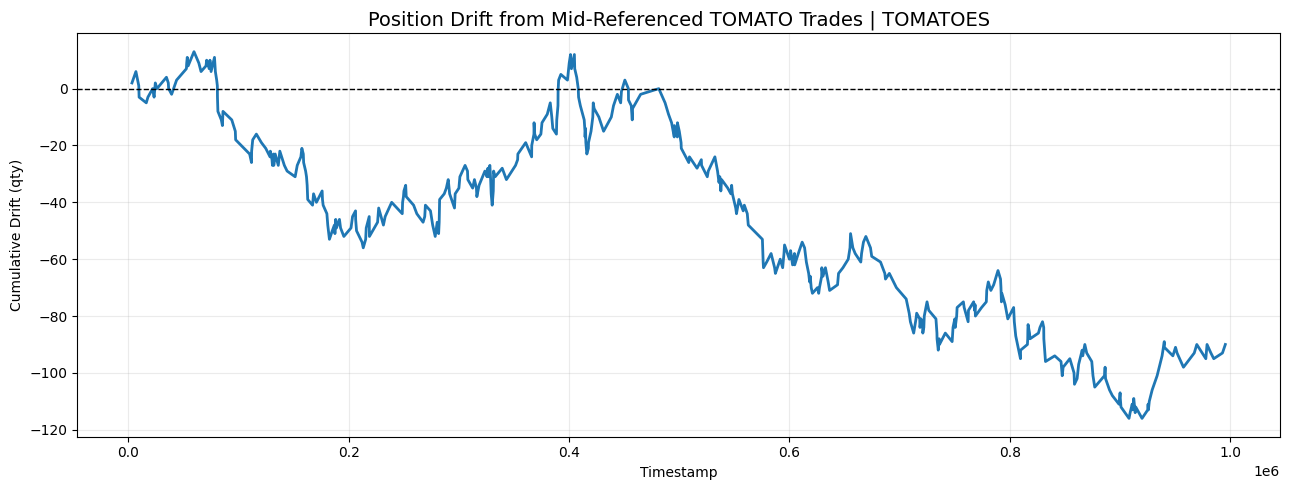

Trades file: trades_round_0_day_-1.csv
Prices file: prices_round_0_day_-1.csv
Total trades used: 423
Positive drift steps: 198
Negative drift steps: 225


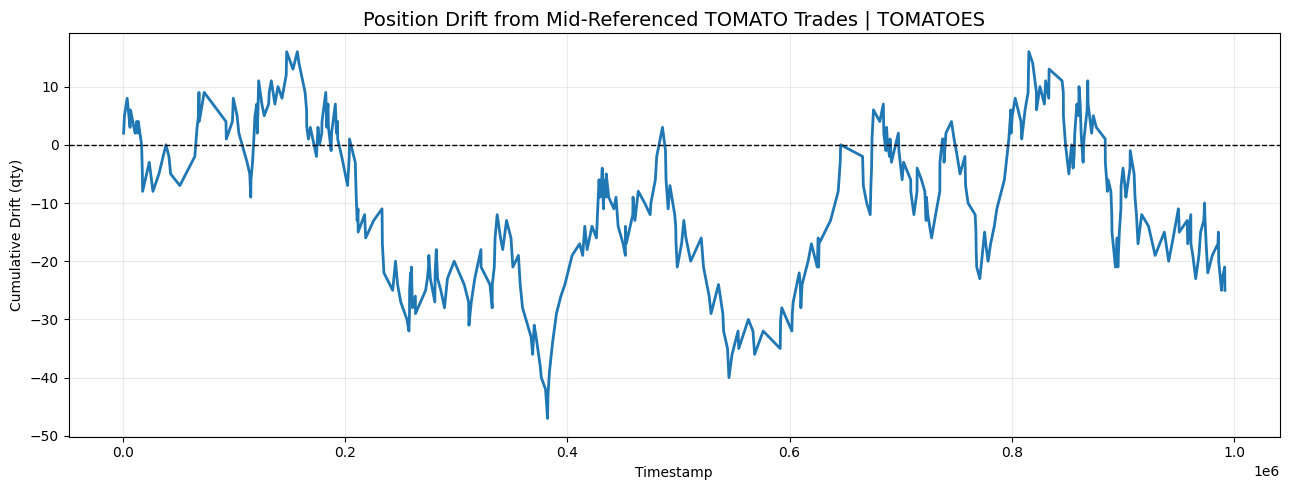

Trades file: trades_round_0_day_-2.csv
Prices file: prices_round_0_day_-2.csv
Total trades used: 397
Positive drift steps: 189
Negative drift steps: 207


In [28]:
tomato_mid_drift_day1 = plot_tomato_position_drift_mid(
    "trades_round_0_day_-1.csv",
    "prices_round_0_day_-1.csv",
    symbol="TOMATOES",
)
tomato_mid_drift_day2 = plot_tomato_position_drift_mid(
    "trades_round_0_day_-2.csv",
    "prices_round_0_day_-2.csv",
    symbol="TOMATOES",
)

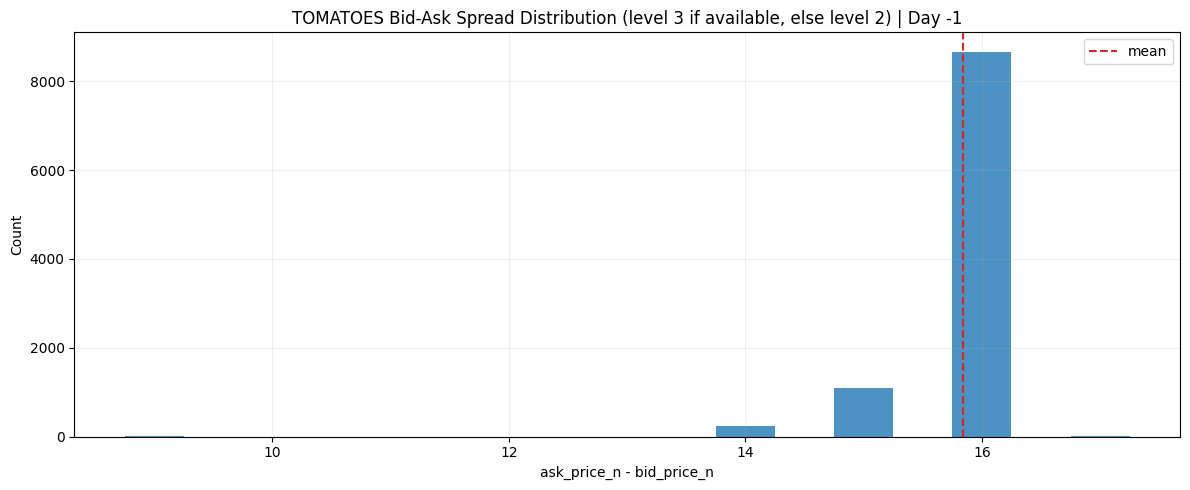

File: prices_round_0_day_-1.csv
Used level: row-wise level 3 when available, otherwise level 2
Rows used: 10000
Mean spread: 15.842
Std spread: 0.441
Spread level counts:
spread_level
2.0    10000
Name: count, dtype: int64


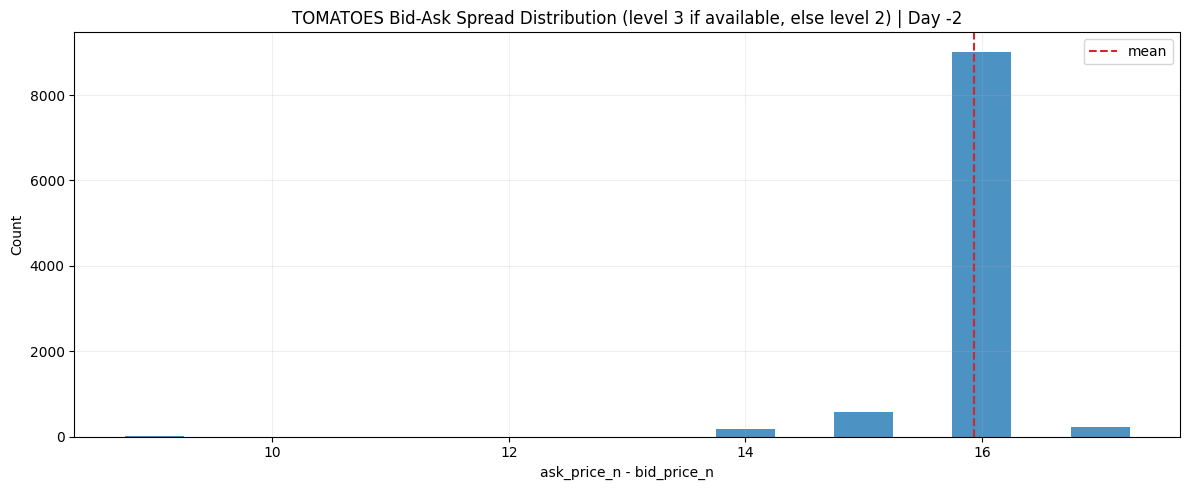

File: prices_round_0_day_-2.csv
Used level: row-wise level 3 when available, otherwise level 2
Rows used: 10000
Mean spread: 15.930
Std spread: 0.398
Spread level counts:
spread_level
2.0    10000
Name: count, dtype: int64


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_tomato_bid_ask_gap_distribution(prices_csv: str, title_prefix: str | None = None) -> pd.DataFrame:
    """Plot the distribution of ask_price_n - bid_price_n for TOMATOES.

    Uses level 3 when both bid_price_3 and ask_price_3 are available for a row;
    otherwise falls back to level 2 for that row.
    Returns the dataframe with the computed spread series.
    """
    df = load_prices(prices_csv)
    sub = df[df["product"] == "TOMATOES"].copy()

    if sub.empty:
        raise ValueError(f"No TOMATOES rows found in {prices_csv}")

    for col in ["bid_price_2", "bid_price_3", "ask_price_2", "ask_price_3"]:
        if col in sub.columns:
            sub[col] = pd.to_numeric(sub[col], errors="coerce")

    required_cols = {"bid_price_2", "bid_price_3", "ask_price_2", "ask_price_3"}
    if not required_cols.issubset(sub.columns):
        raise ValueError("Missing required bid/ask columns for levels 2 and 3.")

    sub = sub[["timestamp", "bid_price_2", "bid_price_3", "ask_price_2", "ask_price_3"]].copy()
    sub = sub.dropna(subset=["timestamp"]).sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last")

    def choose_spread(row: pd.Series) -> pd.Series:
        if pd.notna(row["bid_price_3"]) and pd.notna(row["ask_price_3"]):
            return pd.Series({"spread": float(row["ask_price_3"] - row["bid_price_3"]), "spread_level": 3})
        if pd.notna(row["bid_price_2"]) and pd.notna(row["ask_price_2"]):
            return pd.Series({"spread": float(row["ask_price_2"] - row["bid_price_2"]), "spread_level": 2})
        return pd.Series({"spread": np.nan, "spread_level": np.nan})

    spread_info = sub.apply(choose_spread, axis=1)
    sub = pd.concat([sub, spread_info], axis=1)
    sub = sub[sub["spread"].notna()].copy()

    if sub.empty:
        raise ValueError("No valid spread values found after cleaning.")

    # Use 0.5-wide buckets centered on discrete half-tick values.
    min_x = np.floor(sub["spread"].min() * 2) / 2
    max_x = np.ceil(sub["spread"].max() * 2) / 2
    bins = np.arange(min_x - 0.25, max_x + 0.75, 0.5)

    plt.figure(figsize=(12, 5))
    plt.hist(sub["spread"], bins=bins, color="tab:blue", alpha=0.8)
    plt.axvline(sub["spread"].mean(), color="tab:red", linestyle="--", linewidth=1.5, label="mean")
    plt.title(
        "TOMATOES Bid-Ask Spread Distribution (level 3 if available, else level 2)"
        + (f" | {title_prefix}" if title_prefix else "")
    )
    plt.xlabel("ask_price_n - bid_price_n")
    plt.ylabel("Count")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"File: {prices_csv}")
    print("Used level: row-wise level 3 when available, otherwise level 2")
    print(f"Rows used: {len(sub)}")
    print(f"Mean spread: {sub['spread'].mean():.3f}")
    print(f"Std spread: {sub['spread'].std(ddof=1):.3f}")
    print("Spread level counts:")
    print(sub["spread_level"].value_counts(dropna=False).sort_index())

    return sub


# Plot both days
spread_day1 = plot_tomato_bid_ask_gap_distribution(
    "prices_round_0_day_-1.csv",
    title_prefix="Day -1",
)
spread_day2 = plot_tomato_bid_ask_gap_distribution(
    "prices_round_0_day_-2.csv",
    title_prefix="Day -2",
)

In [30]:
def locate_timestamp_gaps(
    data: pd.DataFrame | pd.Series,
    target_diff: int | float = 17,
    timestamp_col: str = "timestamp",
    product: str | None = None,
) -> pd.DataFrame:
    """Return consecutive timestamp pairs whose difference equals target_diff.

    If `data` is a DataFrame, it is expected to contain a timestamp column and is
    sorted before differences are computed. If `product` is provided and a
    product column exists, the data is filtered first.
    """
    if isinstance(data, pd.Series):
        timestamps = pd.to_numeric(data, errors="coerce")
        timestamps = timestamps.dropna().drop_duplicates().sort_values().reset_index(drop=True)
    else:
        frame = data.copy()
        if product is not None and "product" in frame.columns:
            frame = frame[frame["product"].astype(str).str.strip().str.upper() == product.strip().upper()].copy()

        if timestamp_col not in frame.columns:
            raise ValueError(f"Missing timestamp column: {timestamp_col}")

        timestamps = (
            pd.to_numeric(frame[timestamp_col], errors="coerce")
            .dropna()
            .drop_duplicates()
            .sort_values()
            .reset_index(drop=True)
        )

    if len(timestamps) < 2:
        return pd.DataFrame(columns=["prev_timestamp", "timestamp", "diff"])

    gaps = pd.DataFrame(
        {
            "prev_timestamp": timestamps.shift(1),
            "timestamp": timestamps,
        }
    ).dropna()
    gaps["diff"] = gaps["timestamp"] - gaps["prev_timestamp"]

    if float(target_diff).is_integer():
        target_mask = gaps["diff"] == int(target_diff)
    else:
        target_mask = gaps["diff"] == float(target_diff)

    matches = gaps[target_mask].reset_index(drop=True)
    print(f"Found {len(matches)} timestamp gaps of {target_diff}.")
    return matches


# Example usage:
gaps_17 = locate_timestamp_gaps(load_prices("prices_round_0_day_-2.csv"), target_diff=17, product="TOMATOES")
display(gaps_17)


Found 0 timestamp gaps of 17.


,prev_timestamp,timestamp,diff


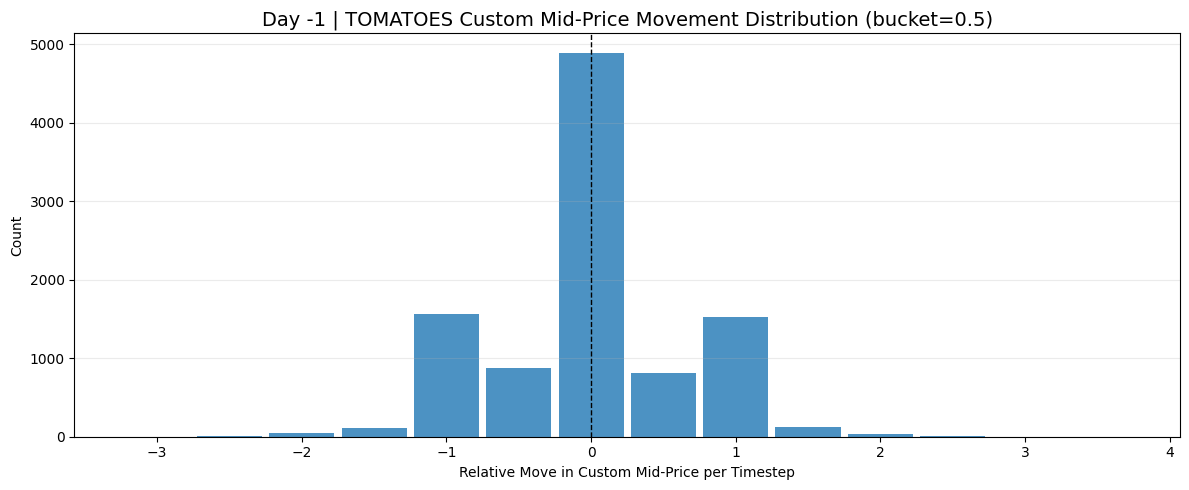

File: prices_round_0_day_-1.csv
Rows with custom-mid values: 10000
Level-3 mids used: 0
Level-2 fallback mids used: 10000


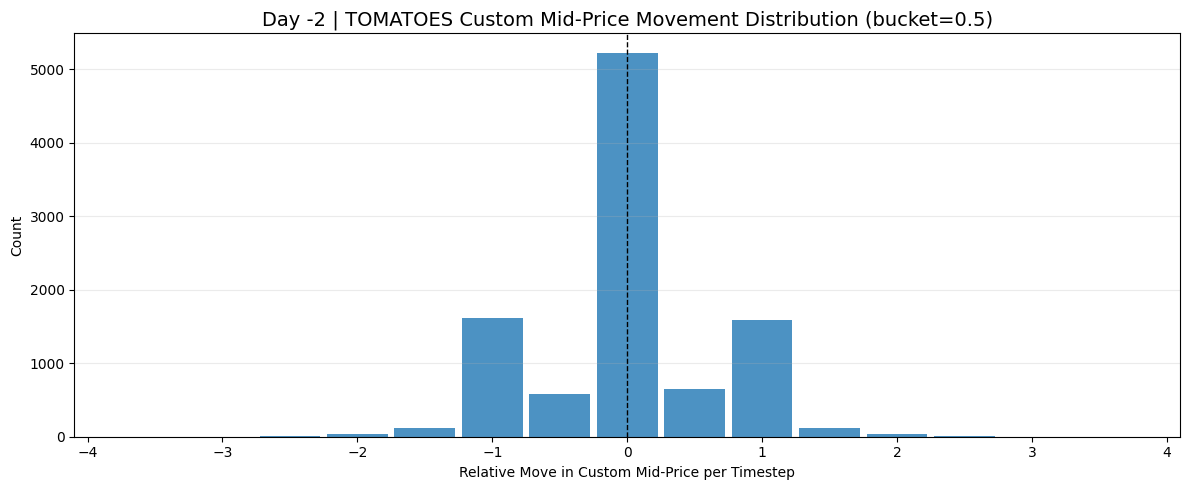

File: prices_round_0_day_-2.csv
Rows with custom-mid values: 10000
Level-3 mids used: 0
Level-2 fallback mids used: 10000


In [31]:
def plot_custom_midprice_movement_distribution(
    prices_csv: str,
    product: str = "TOMATOES",
    step: float = 0.5,
    title_prefix: str | None = None,
) -> pd.DataFrame:
    """Plot movement distribution for a custom mid-price series.

    Custom mid-price rule per timestamp:
      - Use (bid_price_3 + ask_price_3) / 2 when both level-3 values exist
      - Otherwise use (bid_price_2 + ask_price_2) / 2 when both level-2 values exist

    Movement is first-difference of this custom mid-price and then bucketed by `step`.
    """
    if step <= 0:
        raise ValueError("step must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows for product={asset} in file {prices_csv}")

    needed_cols = ["timestamp", "bid_price_2", "ask_price_2", "bid_price_3", "ask_price_3"]
    missing = [c for c in needed_cols if c not in sub.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for c in needed_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    sub = (
        sub[needed_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    level3_ok = sub["bid_price_3"].notna() & sub["ask_price_3"].notna()
    level2_ok = sub["bid_price_2"].notna() & sub["ask_price_2"].notna()

    sub["custom_mid"] = np.nan
    sub.loc[level3_ok, "custom_mid"] = (sub.loc[level3_ok, "bid_price_3"] + sub.loc[level3_ok, "ask_price_3"]) / 2.0

    level2_fallback = (~level3_ok) & level2_ok
    sub.loc[level2_fallback, "custom_mid"] = (
        sub.loc[level2_fallback, "bid_price_2"] + sub.loc[level2_fallback, "ask_price_2"]
    ) / 2.0

    sub = sub.dropna(subset=["custom_mid"]).copy()
    if len(sub) < 2:
        raise ValueError("Need at least two valid custom-mid points to compute movement.")

    sub["mid_move"] = sub["custom_mid"].diff()
    moves = sub["mid_move"].dropna()

    if moves.empty:
        raise ValueError("No custom-mid movements available after differencing.")

    bucketed = (moves / step).round() * step
    dist = bucketed.value_counts().sort_index().to_frame(name="count")
    dist["probability"] = dist["count"] / dist["count"].sum()

    plt.figure(figsize=(12, 5))
    plt.bar(dist.index, dist["count"], width=step * 0.9, color="tab:blue", alpha=0.8)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    title = f"{asset} Custom Mid-Price Movement Distribution (bucket={step})"
    if title_prefix:
        title = f"{title_prefix} | {title}"

    plt.title(title, fontsize=14)
    plt.xlabel("Relative Move in Custom Mid-Price per Timestep")
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"File: {prices_csv}")
    print(f"Rows with custom-mid values: {len(sub)}")
    print(f"Level-3 mids used: {int(level3_ok.sum())}")
    print(f"Level-2 fallback mids used: {int(level2_fallback.sum())}")

    return dist


# Example usage
custom_mid_move_day1 = plot_custom_midprice_movement_distribution(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
    step=0.5,
    title_prefix="Day -1",
)

custom_mid_move_day2 = plot_custom_midprice_movement_distribution(
    "prices_round_0_day_-2.csv",
    product="TOMATOES",
    step=0.5,
    title_prefix="Day -2",
)


In [ ]:
def run_price_levels_window_widget(
    prices_csv: str,
    product: str = "TOMATOES",
    window_size: int = 50,
    trades_csv: str = "trades_round_0_day_-1.csv",
) -> None:
    """Interactive plot of mid/bid/ask price levels with trade overlays."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    trades_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trade_cols = {"timestamp", "symbol", "price"}
    missing_trade_cols = required_trade_cols - set(trades.columns)
    if missing_trade_cols:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trade_cols)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price"])
    trades = trades[trades["symbol"] == asset].copy()

    # Custom midpoint: average(highest ask, lowest bid), where each side uses level 3 if
    # available, otherwise level 2.
    if {"ask_price_2", "ask_price_3"}.issubset(sub.columns):
        sub["best_ask_fallback"] = sub["ask_price_3"].where(sub["ask_price_3"].notna(), sub["ask_price_2"])
    else:
        sub["best_ask_fallback"] = np.nan

    if {"bid_price_2", "bid_price_3"}.issubset(sub.columns):
        sub["best_bid_fallback"] = sub["bid_price_3"].where(sub["bid_price_3"].notna(), sub["bid_price_2"])
    else:
        sub["best_bid_fallback"] = np.nan

    sub["fallback_mid"] = (sub["best_ask_fallback"] + sub["best_bid_fallback"]) / 2.0

    # Additional fallback quote ladders for dotted overlays.
    if {"ask_price_1", "ask_price_2"}.issubset(sub.columns):
        sub["second_ask_fallback"] = sub["ask_price_2"].where(sub["ask_price_2"].notna(), sub["ask_price_1"])
    else:
        sub["second_ask_fallback"] = np.nan

    if {"bid_price_1", "bid_price_2"}.issubset(sub.columns):
        sub["second_bid_fallback"] = sub["bid_price_2"].where(sub["bid_price_2"].notna(), sub["bid_price_1"])
    else:
        sub["second_bid_fallback"] = np.nan

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "mid_price" in w.columns and w["mid_price"].notna().any():
            plt.plot(w["timestamp"], w["mid_price"], color="black", linewidth=2.0, label="mid_price")

        if "fallback_mid" in w.columns and w["fallback_mid"].notna().any():
            plt.plot(
                w["timestamp"],
                w["fallback_mid"],
                color="tab:blue",
                linestyle=":",
                linewidth=2.0,
                alpha=0.95,
                label="fallback_mid (ask3/2 + bid3/2)/2",
            )

        # Dotted fallback quote lines:
        # highest ask (ask3 else ask2), second highest ask (ask2 else ask1),
        # lowest bid (bid3 else bid2), second lowest bid (bid2 else bid1).
        if "best_ask_fallback" in w.columns and w["best_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_ask_fallback"],
                color="#B71C1C",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="highest ask fallback (3->2)",
            )

        if "second_ask_fallback" in w.columns and w["second_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_ask_fallback"],
                color="#E57373",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second highest ask fallback (2->1)",
            )

        if "best_bid_fallback" in w.columns and w["best_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_bid_fallback"],
                color="#1B5E20",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="lowest bid fallback (3->2)",
            )

        if "second_bid_fallback" in w.columns and w["second_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_bid_fallback"],
                color="#81C784",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second lowest bid fallback (2->1)",
            )

        bid_colors = ["#A5D6A7", "#4CAF50", "#1B5E20"]
        if "bid_price_1" in w.columns and w["bid_price_1"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_1"], color=bid_colors[0], linewidth=1.4, alpha=0.95, label="bid_price_1")
        if "bid_price_2" in w.columns and w["bid_price_2"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_2"], color=bid_colors[1], linewidth=1.4, alpha=0.95, label="bid_price_2")
        if "bid_price_3" in w.columns and w["bid_price_3"].notna().any():
            b3 = w[w["bid_price_3"].notna()]
            plt.scatter(b3["timestamp"], b3["bid_price_3"], color=bid_colors[2], s=20, alpha=0.95, label="bid_price_3 (points)")

        ask_colors = ["#FF7F7F", "#D32F2F", "#7B0000"]
        if "ask_price_1" in w.columns and w["ask_price_1"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_1"], color=ask_colors[0], linewidth=1.4, alpha=0.95, label="ask_price_1")
        if "ask_price_2" in w.columns and w["ask_price_2"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_2"], color=ask_colors[1], linewidth=1.4, alpha=0.95, label="ask_price_2")
        if "ask_price_3" in w.columns and w["ask_price_3"].notna().any():
            a3 = w[w["ask_price_3"].notna()]
            plt.scatter(a3["timestamp"], a3["ask_price_3"], color=ask_colors[2], s=20, alpha=0.95, label="ask_price_3 (points)")

        # Overlay trades in current window as X markers.
        t_min = w["timestamp"].min()
        t_max = w["timestamp"].max()
        tw = trades[(trades["timestamp"] >= t_min) & (trades["timestamp"] <= t_max)]
        if not tw.empty:
            plt.scatter(
                tw["timestamp"],
                tw["price"],
                marker="x",
                color="#EFB63A",
                s=72,
                linewidths=3.2,
                alpha=0.9,
                label=f"trades ({len(tw)})",
            )

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Price Levels | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


# Example usage:
run_price_levels_window_widget(
    "prices_round_0_day_-1.csv",
    product="TOMATOES",
    window_size=50,
    trades_csv="trades_round_0_day_-1.csv",
)


Output()

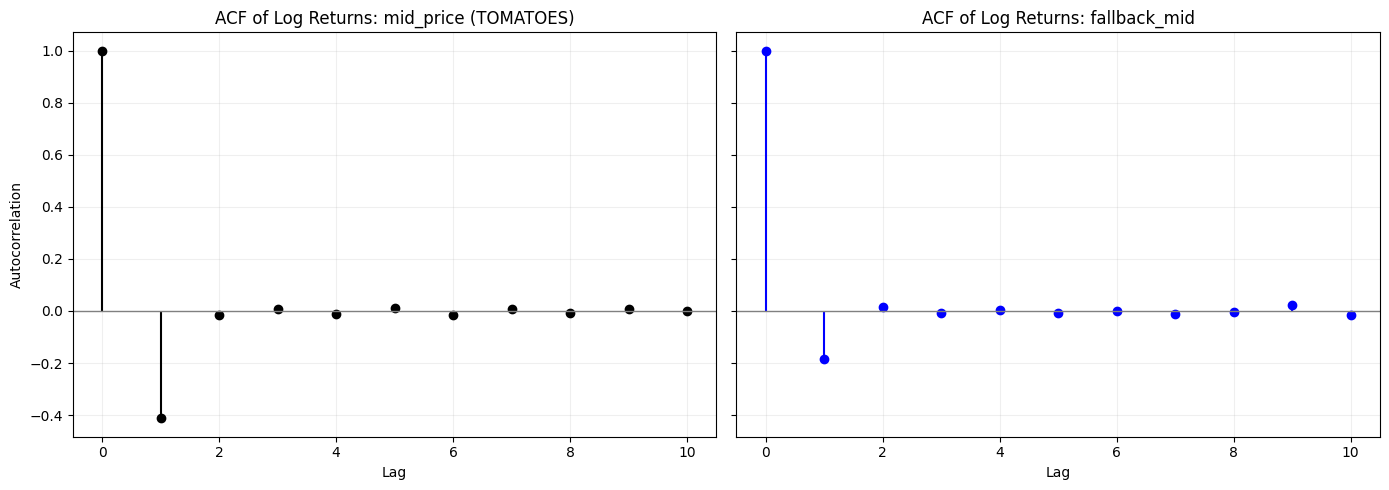

In [33]:
# Autocorrelation of log returns for mid_price and fallback_mid
prices_csv = "prices_round_0_day_-1.csv"
product = "TOMATOES"
max_lag = 10

asset = product.strip().upper()
df = load_prices(prices_csv)
sub = df[df["product"] == asset].copy()

cols = [
    "timestamp",
    "mid_price",
    "bid_price_2", "bid_price_3",
    "ask_price_2", "ask_price_3",
]
available_cols = [c for c in cols if c in sub.columns]

for c in available_cols:
    sub[c] = pd.to_numeric(sub[c], errors="coerce")

sub = (
    sub[available_cols]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

sub["best_ask_fallback"] = sub["ask_price_3"].where(sub["ask_price_3"].notna(), sub["ask_price_2"])
sub["best_bid_fallback"] = sub["bid_price_3"].where(sub["bid_price_3"].notna(), sub["bid_price_2"])
sub["fallback_mid"] = (sub["best_ask_fallback"] + sub["best_bid_fallback"]) / 2.0

mid_series = sub["mid_price"].dropna().reset_index(drop=True)
fb_series = sub["fallback_mid"].dropna().reset_index(drop=True)

# Log returns: r_t = log(p_t) - log(p_{t-1})
mid_logret = np.log(mid_series).diff().replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
fb_logret = np.log(fb_series).diff().replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

max_lag_mid = min(max_lag, max(1, len(mid_logret) - 1))
max_lag_fb = min(max_lag, max(1, len(fb_logret) - 1))

lags_mid = np.arange(max_lag_mid + 1)
lags_fb = np.arange(max_lag_fb + 1)

acf_mid = [1.0] + [mid_logret.autocorr(lag=int(k)) for k in lags_mid[1:]]
acf_fb = [1.0] + [fb_logret.autocorr(lag=int(k)) for k in lags_fb[1:]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].stem(lags_mid, acf_mid, linefmt="k-", markerfmt="ko", basefmt=" ")
axes[0].axhline(0.0, color="gray", linewidth=1)
axes[0].set_title(f"ACF of Log Returns: mid_price ({asset})")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(alpha=0.2)

axes[1].stem(lags_fb, acf_fb, linefmt="b-", markerfmt="bo", basefmt=" ")
axes[1].axhline(0.0, color="gray", linewidth=1)
axes[1].set_title("ACF of Log Returns: fallback_mid")
axes[1].set_xlabel("Lag")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

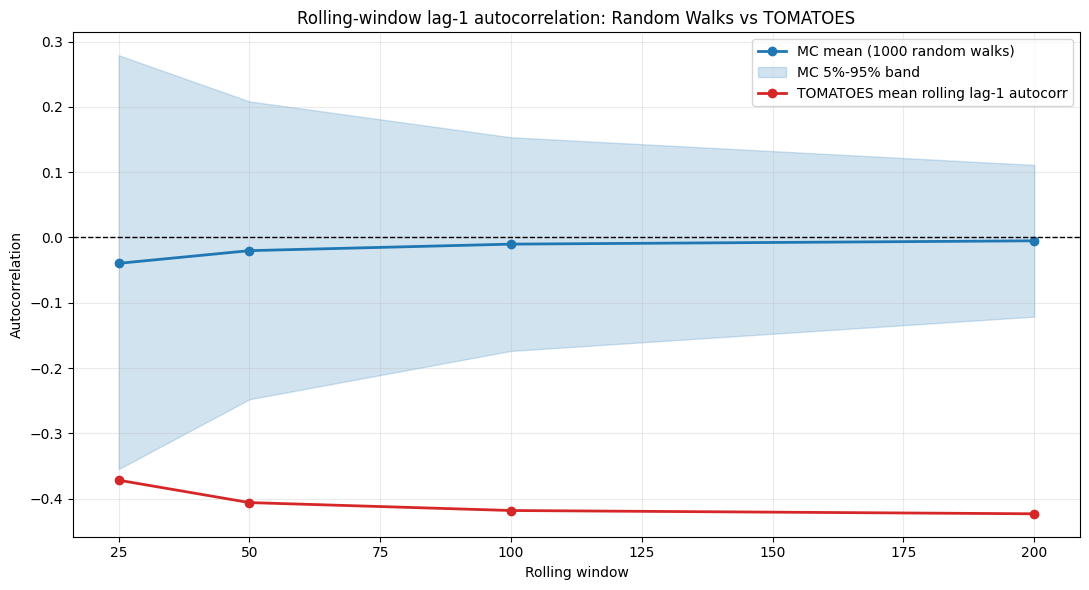

,window,tomatoes_mean_autocorr,mc_mean_autocorr,mc_q05,mc_q95
0,25,-0.371731,-0.039608,-0.354782,0.279077
1,50,-0.406040,-0.020168,-0.247775,0.208373
2,100,-0.418164,-0.010187,-0.173721,0.153488
3,200,-0.423193,-0.005113,-0.121230,0.111084


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Monte Carlo benchmark: rolling lag-1 autocorrelation for random-walk returns
# compared against TOMATOES log-return autocorrelation.
prices_csv = "prices_round_0_day_-2.csv"
product = "TOMATOES"
windows = [25, 50, 100, 200]
n_sims = 1000
seed = 42


def _resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _load_prices_fallback(path: str) -> pd.DataFrame:
    file_path = _resolve_data_path(path)
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


# Use existing helper if available; otherwise parse locally.
if "load_prices" in globals():
    df = load_prices(prices_csv)
else:
    df = _load_prices_fallback(prices_csv)

asset = product.strip().upper()
sub = df[df["product"].astype(str).str.strip().str.upper() == asset].copy()

if sub.empty:
    raise ValueError(f"No rows found for product={asset} in {prices_csv}")

sub["timestamp"] = pd.to_numeric(sub["timestamp"], errors="coerce")
sub["mid_price"] = pd.to_numeric(sub["mid_price"], errors="coerce")
sub = (
    sub[["timestamp", "mid_price"]]
    .dropna(subset=["timestamp", "mid_price"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Log returns of TOMATOES mid price.
ret = np.log(sub["mid_price"]).diff().replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
if len(ret) < max(windows) + 2:
    raise ValueError(
        f"Not enough return points ({len(ret)}) for requested windows {windows}. "
        "Use smaller windows or a longer sample."
    )


def rolling_lag1_autocorr(x: pd.Series, window: int) -> pd.Series:
    return x.rolling(window=window, min_periods=window).corr(x.shift(1)).dropna()


# Tomatoes rolling autocorrelation summary by window.
tom_means = []
for w in windows:
    r = rolling_lag1_autocorr(ret, w)
    tom_means.append(float(r.mean()))

# Monte Carlo: simulate random-walk returns with same variance scale as TOMATOES returns.
rng = np.random.default_rng(seed)
ret_std = float(ret.std(ddof=1))
T = len(ret)

mc_mean = []
mc_q05 = []
mc_q95 = []

for w in windows:
    pooled = []
    for _ in range(n_sims):
        sim_ret = pd.Series(rng.normal(loc=0.0, scale=ret_std, size=T))
        sim_roll = rolling_lag1_autocorr(sim_ret, w)
        if len(sim_roll) > 0:
            pooled.append(sim_roll.to_numpy())

    if not pooled:
        raise ValueError(f"No Monte Carlo rolling autocorrelation values for window={w}")

    pooled_vals = np.concatenate(pooled)
    mc_mean.append(float(np.mean(pooled_vals)))
    mc_q05.append(float(np.quantile(pooled_vals, 0.05)))
    mc_q95.append(float(np.quantile(pooled_vals, 0.95)))

# Plot MC benchmark and TOMATOES on the same graph.
plt.figure(figsize=(11, 6))
plt.plot(windows, mc_mean, marker="o", linewidth=2, color="tab:blue", label=f"MC mean ({n_sims} random walks)")
plt.fill_between(windows, mc_q05, mc_q95, color="tab:blue", alpha=0.2, label="MC 5%-95% band")
plt.plot(windows, tom_means, marker="o", linewidth=2, color="tab:red", label=f"{asset} mean rolling lag-1 autocorr")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Rolling-window lag-1 autocorrelation: Random Walks vs {asset}")
plt.xlabel("Rolling window")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "window": windows,
        "tomatoes_mean_autocorr": tom_means,
        "mc_mean_autocorr": mc_mean,
        "mc_q05": mc_q05,
        "mc_q95": mc_q95,
    }
)

Signicicant autocorrelation